# 🐼 Pandas — Zero to Advanced: Comprehensive Notes & Scripts
**Author:** Notes Maintainer | **Dataset:** `sample.csv` (10 employee records)

This notebook covers every core concept in Pandas from absolute basics to advanced techniques.
Work through each section in order — every concept builds on the previous one.



---
## 1. What is Pandas?

**Pandas** is an open-source Python library for **data manipulation and analysis**.

Think of it like a super-powered **Excel/spreadsheet** that lives inside Python.

### Why Pandas?
| Task | Without Pandas | With Pandas |
|---|---|---|
| Load a CSV | 10+ lines with `csv` module | 1 line: `pd.read_csv()` |
| Filter rows | Nested loops | `df[df['age'] > 30]` |
| Group & aggregate | Complex dicts | `df.groupby('dept')['salary'].mean()` |
| Handle missing data | Manual checks | `.fillna()`, `.dropna()` |

### Installing Pandas
```
pip install pandas          # install
pip install pandas openpyxl # install with Excel support
```

### Before We Start: Creating Our Dataset

Every section in this notebook uses a file called `sample.csv`. 

**What is a CSV?**  
CSV stands for **Comma-Separated Values** — it's the simplest way to store table data as plain text. Open any CSV in Notepad and you'd see:

```
id,name,age,department,salary,city
1,Alice,25,Engineering,75000,Mumbai
2,Bob,30,HR,50000,Chennai
```

The **first row** is the header (column names). Every row after that is one record.  
Commas separate the columns — that's why it's called comma-separated.

Run the cell below **first** to create the dataset. Every other cell in this notebook depends on it.


In [ ]:
import pandas as pd
import numpy as np
import os

# ── Create sample.csv so every cell in this notebook can run ─────────────────
csv_data = """id,name,age,department,salary,city
1,Alice,25,Engineering,75000,Mumbai
2,Bob,30,HR,50000,Chennai
3,Charlie,28,Engineering,82000,Bengaluru
4,David,35,Finance,91000,Delhi
5,Eva,26,Marketing,62000,Pune
6,Frank,32,Engineering,88000,Hyderabad
7,Grace,29,HR,54000,Mumbai
8,Helen,31,Finance,79000,Chennai
9,Ivan,27,Marketing,58000,Delhi
10,Julia,33,Engineering,95000,Bengaluru"""

CSV_PATH = "sample.csv"
with open(CSV_PATH, "w") as f:
    f.write(csv_data)

print("✅ sample.csv created successfully!")
print()

# Peek at what the raw CSV looks like (first 3 lines)
with open(CSV_PATH) as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 3:
            print("  ... (6 more rows)")
            break


In [ ]:
# ── Standard imports used throughout this notebook ───────────────────────────
import pandas as pd    # the main library — always aliased 'pd' by convention
import numpy as np     # numerical computing — pandas is built on top of numpy

# A note on CSV_PATH — set it once here so every cell can use it
CSV_PATH = "sample.csv"

print("Pandas version:", pd.__version__)
print("NumPy  version:", np.__version__)
print("CSV_PATH set to:", CSV_PATH)


---
## 2. Core Data Structures

Pandas has two primary data structures:

| Structure | Dimensions | Analogy |
|---|---|---|
| **Series** | 1-D (single column) | A single Excel column |
| **DataFrame** | 2-D (rows × columns) | A full Excel sheet |

---
### Series

A **Series** is a one-dimensional array with labels (called an **index**).

```
Index   Values
------  ------
  0      Alice
  1        Bob
  2    Charlie
```

### Mental Model: How to Think About Series and DataFrame

```
SERIES — like a single Excel column with row labels:

 Index  │ Value
────────┼────────
 Alice  │  75000   ← each (index, value) pair is one element
 Bob    │  50000
 Charlie│  82000

DATAFRAME — like a full Excel sheet; a collection of Series sharing the same index:

 Index │ name    │ age │ department  │ salary │ city
───────┼─────────┼─────┼─────────────┼────────┼──────────
   0   │ Alice   │  25 │ Engineering │  75000 │ Mumbai
   1   │ Bob     │  30 │ HR          │  50000 │ Chennai
   2   │ Charlie │  28 │ Engineering │  82000 │ Bengaluru
   ...
```

**Key insight:** Every column in a DataFrame IS a Series.  
`df['salary']` gives you the salary Series — a standalone 1-D object.

**The index** (the 0, 1, 2 … on the left) is the row label — like a row name.  
By default it's just 0, 1, 2 … but you can set it to anything (e.g. employee names).


In [212]:
# ── Creating a Series ──────────────────────────────────────────────────────

# From a Python list (index auto-assigned as 0,1,2,...)
s1 = pd.Series([10, 20, 30, 40])
print("Series from list:")
print(s1)
print()

# From a list WITH custom index labels
s2 = pd.Series([75000, 50000, 82000], index=['Alice', 'Bob', 'Charlie'])
print("Series with custom index:")
print(s2)
print()

# From a Python dictionary (keys become index)
s3 = pd.Series({'Engineering': 88000, 'HR': 52000, 'Finance': 85000})
print("Series from dict:")
print(s3)

Series from list:
0    10
1    20
2    30
3    40
dtype: int64

Series with custom index:
Alice      75000
Bob        50000
Charlie    82000
dtype: int64

Series from dict:
Engineering    88000
HR             52000
Finance        85000
dtype: int64


In [213]:
# ── Series Attributes ─────────────────────────────────────────────────────

s = pd.Series([75000, 50000, 82000, 91000], index=['Alice', 'Bob', 'Charlie', 'David'])

print("Values (NumPy array):", s.values)
print("Index:               ", s.index.tolist())
print("Data type:           ", s.dtype)
print("Number of elements:  ", len(s))
print("Shape:               ", s.shape)
print("Name:                ", s.name)   # None until set

s.name = 'salary'
print("After naming:        ", s.name)

Values (NumPy array): [75000 50000 82000 91000]
Index:                ['Alice', 'Bob', 'Charlie', 'David']
Data type:            int64
Number of elements:   4
Shape:                (4,)
Name:                 None
After naming:         salary


In [214]:
# ── Accessing Elements in a Series ────────────────────────────────────────

s = pd.Series([75000, 50000, 82000, 91000], index=['Alice', 'Bob', 'Charlie', 'David'])

# By label (index name)
print("Alice's salary:", s['Alice'])

# By position (like a list)
print("First element :", s.iloc[0])

# Slicing by position
print("First two     :\n", s.iloc[:2])

# Boolean mask on a Series
print("Salary > 80000:\n", s[s > 80000])

Alice's salary: 75000
First element : 75000
First two     :
 Alice    75000
Bob      50000
dtype: int64
Salary > 80000:
 Charlie    82000
David      91000
dtype: int64


In [215]:
# ── Basic Series Operations ────────────────────────────────────────────────

s = pd.Series([75000, 50000, 82000, 91000])

print("Sum    :", s.sum())
print("Mean   :", s.mean())
print("Max    :", s.max())
print("Min    :", s.min())
print("Std Dev:", round(s.std(), 2))

# Arithmetic — operations are element-wise
print("\nAll salaries + 5000 raise:")
print(s + 5000)

print("\n10% salary increase:")
print(s * 1.10)

Sum    : 298000
Mean   : 74500.0
Max    : 91000
Min    : 50000
Std Dev: 17597.35

All salaries + 5000 raise:
0    80000
1    55000
2    87000
3    96000
dtype: int64

10% salary increase:
0     82500.0
1     55000.0
2     90200.0
3    100100.0
dtype: float64


---
### DataFrame

A **DataFrame** is a 2-dimensional table with:
- **Rows** identified by an **index** (default 0, 1, 2 …)
- **Columns** identified by **column names**

```
   id    name  age   department  salary    city
0   1   Alice   25  Engineering   75000  Mumbai
1   2     Bob   30           HR   50000  Chennai
...
```
Every column in a DataFrame is a **Series**.

In [216]:
# ── Creating a DataFrame manually ─────────────────────────────────────────

# From a Python dictionary (keys = column names, values = lists)
data = {
    'name'      : ['Alice', 'Bob', 'Charlie', 'David'],
    'age'       : [25, 30, 28, 35],
    'salary'    : [75000, 50000, 82000, 91000],
    'department': ['Engineering', 'HR', 'Engineering', 'Finance'],
}

df = pd.DataFrame(data)
print(df)
print()
print("Type:", type(df))

      name  age  salary   department
0    Alice   25   75000  Engineering
1      Bob   30   50000           HR
2  Charlie   28   82000  Engineering
3    David   35   91000      Finance

Type: <class 'pandas.core.frame.DataFrame'>


In [217]:
# From a list of dictionaries (each dict = one row)
rows = [
    {'name': 'Alice',   'age': 25, 'salary': 75000},
    {'name': 'Bob',     'age': 30, 'salary': 50000},
    {'name': 'Charlie', 'age': 28, 'salary': 82000},
]
df2 = pd.DataFrame(rows)
print(df2)

      name  age  salary
0    Alice   25   75000
1      Bob   30   50000
2  Charlie   28   82000


In [218]:
# From a NumPy array (must supply column names separately)
arr = np.array([[1, 25, 75000], [2, 30, 50000], [3, 28, 82000]])
df3 = pd.DataFrame(arr, columns=['id', 'age', 'salary'])
print(df3)

   id  age  salary
0   1   25   75000
1   2   30   50000
2   3   28   82000


---
### 🚨 Critical Concept: Most Pandas Operations Return a NEW DataFrame

This is the **#1 source of confusion** for beginners.

In Python, `x + 1` doesn't change `x` — it returns a new value.  
Pandas works the same way for almost all operations:

```python
df_sorted = df.sort_values('salary')   # ✅ df_sorted is a new DataFrame
print(df)                               # df is UNCHANGED — original order

df.sort_values('salary')               # ❌ result thrown away! Nothing is saved.
df.sort_values('salary', inplace=True) # ✅ modifies df directly (use sparingly)
```

**Rule of thumb:** Always assign the result back:
```python
df = df.sort_values('salary')          # overwrite df with the sorted version
# or
df_sorted = df.sort_values('salary')   # keep both the original and sorted
```

Operations that DO modify in-place (no need to reassign):
- `df['new_col'] = ...`   — adding/replacing a column
- `df.sort_values(inplace=True)`
- `list.append()`, `dict.update()` — but these are plain Python, not pandas


---
## 3. Reading & Writing Data

### Reading CSV — `pd.read_csv()`

This is the most common way to load data into Pandas.

| Parameter | Purpose | Example |
|---|---|---|
| `filepath` | Path to the file | `'data.csv'` |
| `sep` | Delimiter character | `sep=';'` for semicolon |
| `header` | Row number for column names | `header=0` (default) |
| `index_col` | Column to use as index | `index_col='id'` |
| `usecols` | Load only specific columns | `usecols=['name','salary']` |
| `nrows` | Load only N rows | `nrows=5` |
| `dtype` | Force column data types | `dtype={'salary': float}` |
| `na_values` | Extra strings to treat as NaN | `na_values=['N/A', '-']` |
| `encoding` | File encoding | `encoding='utf-8'` |

In [219]:
import os

# Build path relative to this notebook's location
BASE = os.path.dirname(os.path.abspath('pandas_learn.ipynb'))
CSV_PATH = os.path.join(BASE, 'sample.csv')

# Basic load
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)   # (rows, columns)
print()
print(df)

Shape: (10, 6)

   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru
3   4    David   35      Finance   91000  Hyderabad
4   5      Eva   26    Marketing   62000       Pune
5   6    Frank   32  Engineering   88000      Delhi
6   7    Grace   29      Finance   79000    Kolkata
7   8    Helen   31           HR   54000     Mumbai
8   9      Ian   27    Marketing   61000    Chennai
9  10     Jane   24  Engineering   70000  Bengaluru


In [220]:
# Load with specific options
df_opts = pd.read_csv(
    CSV_PATH,
    index_col='id',               # use 'id' column as the row index
    dtype={'salary': float},      # force salary to float
    usecols=['id','name','age','department','salary','city']
)
print(df_opts)
print("\nIndex:", df_opts.index.tolist())

       name  age   department   salary       city
id                                               
1     Alice   25  Engineering  75000.0     Mumbai
2       Bob   30           HR  50000.0    Chennai
3   Charlie   28  Engineering  82000.0  Bengaluru
4     David   35      Finance  91000.0  Hyderabad
5       Eva   26    Marketing  62000.0       Pune
6     Frank   32  Engineering  88000.0      Delhi
7     Grace   29      Finance  79000.0    Kolkata
8     Helen   31           HR  54000.0     Mumbai
9       Ian   27    Marketing  61000.0    Chennai
10     Jane   24  Engineering  70000.0  Bengaluru

Index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [221]:
# ── Other read functions (not executed, just shown) ──────────────────────

# pd.read_excel('file.xlsx', sheet_name='Sheet1')  ← needs openpyxl
# pd.read_json('file.json')
# pd.read_sql(query, connection)                   ← from a database
# pd.read_html('https://example.com/table')[0]     ← scrape HTML tables
# pd.read_parquet('file.parquet')                  ← columnar format (fast)
# pd.read_clipboard()                              ← paste from clipboard

print("Reading functions overview — see comments above.")

Reading functions overview — see comments above.


In [222]:
# ── Writing / Exporting ────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)

# CSV — most portable
df.to_csv('output.csv', index=False)        # index=False → don't write row numbers
print("Written: output.csv")

# JSON
df.to_json('output.json', orient='records', indent=2)
print("Written: output.json")

# Excel (needs openpyxl)
try:
    df.to_excel('output.xlsx', index=False, sheet_name='Employees')
    print("Written: output.xlsx")
except ImportError:
    print("openpyxl not installed — Excel export skipped")

# Parquet — efficient binary format
try:
    df.to_parquet('output.parquet', index=False)
    print("Written: output.parquet")
except Exception as e:
    print(f"Parquet skipped: {e}")

import os
for f in ['output.csv','output.json','output.xlsx','output.parquet']:
    if os.path.exists(f): os.remove(f)

Written: output.csv
Written: output.json
Written: output.xlsx
Written: output.parquet


---
## 4. Exploring a DataFrame

When you load new data, the first step is always **exploration** — understanding
what the data looks like before doing anything with it.

In [223]:
df = pd.read_csv(CSV_PATH)

# ── Shape & dimensions ────────────────────────────────────────────────────
print("Shape    :", df.shape)           # (rows, columns)
print("Rows     :", df.shape[0])
print("Columns  :", df.shape[1])
print("Size     :", df.size)            # total number of cells = rows × columns
print("Ndim     :", df.ndim)            # always 2 for DataFrames

Shape    : (10, 6)
Rows     : 10
Columns  : 6
Size     : 60
Ndim     : 2


In [224]:
df = pd.read_csv(CSV_PATH)

# ── Peeking at the data ───────────────────────────────────────────────────
print("=== First 3 rows ===")
print(df.head(3))       # default is 5

print("\n=== Last 3 rows ===")
print(df.tail(3))       # default is 5

print("\n=== Random sample of 3 rows ===")
print(df.sample(3, random_state=42))   # random_state makes it reproducible

=== First 3 rows ===
   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru

=== Last 3 rows ===
   id   name  age   department  salary       city
7   8  Helen   31           HR   54000     Mumbai
8   9    Ian   27    Marketing   61000    Chennai
9  10   Jane   24  Engineering   70000  Bengaluru

=== Random sample of 3 rows ===
   id   name  age   department  salary     city
8   9    Ian   27    Marketing   61000  Chennai
1   2    Bob   30           HR   50000  Chennai
5   6  Frank   32  Engineering   88000    Delhi


In [225]:
df = pd.read_csv(CSV_PATH)

# ── Column names & index ─────────────────────────────────────────────────
print("Columns :", df.columns.tolist())
print("Index   :", df.index.tolist())   # [0,1,2,...9] by default

Columns : ['id', 'name', 'age', 'department', 'salary', 'city']
Index   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [226]:
df = pd.read_csv(CSV_PATH)

# ── Data types ────────────────────────────────────────────────────────────
# 'dtype' tells you what kind of data each column holds:
#   int64   → whole numbers
#   float64 → decimal numbers
#   object  → strings / mixed types
#   bool    → True/False
#   datetime64 → dates
print(df.dtypes)

id             int64
name          object
age            int64
department    object
salary         int64
city          object
dtype: object


#### Understanding dtypes — especially `object`

When you print `df.dtypes`, you'll see something like:

```
id              int64
name           object    ← ⚠️ this means STRING (not numeric)
age             int64
department     object    ← string
salary          int64
city           object    ← string
```

**Why does Pandas call strings `object` instead of `string`?**  
Historically, Pandas stored text as Python `object` references (pointers to Python strings).  
It's confusing but `object` = string for practical purposes.

Newer Pandas (1.0+) has a proper `StringDtype` (`pd.StringDtype()`), but `object` is still the default when you load a CSV.

**Common dtypes:**
| dtype | Meaning | Example values |
|---|---|---|
| `int64` | whole number | 1, 42, -7 |
| `float64` | decimal number | 3.14, -0.5 |
| `object` | string / mixed | "Alice", "HR" |
| `bool` | True or False | True, False |
| `datetime64[ns]` | date & time | 2024-01-15 |
| `category` | limited set of strings | "Low","Mid","High" |


In [227]:
df = pd.read_csv(CSV_PATH)

# ── df.info() — one-stop summary ─────────────────────────────────────────
# Shows: index type, column names, non-null count, dtypes, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          10 non-null     int64 
 1   name        10 non-null     object
 2   age         10 non-null     int64 
 3   department  10 non-null     object
 4   salary      10 non-null     int64 
 5   city        10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


In [228]:
df = pd.read_csv(CSV_PATH)

# ── df.describe() — statistical summary ──────────────────────────────────
# By default shows ONLY numeric columns
print("=== Numeric columns ===")
print(df.describe())

print()
# To include string/object columns:
print("=== All columns (include='all') ===")
print(df.describe(include='all'))

=== Numeric columns ===
             id       age        salary
count  10.00000  10.00000     10.000000
mean    5.50000  28.70000  71200.000000
std     3.02765   3.40098  14148.419621
min     1.00000  24.00000  50000.000000
25%     3.25000  26.25000  61250.000000
50%     5.50000  28.50000  72500.000000
75%     7.75000  30.75000  81250.000000
max    10.00000  35.00000  91000.000000

=== All columns (include='all') ===
              id   name       age   department        salary    city
count   10.00000     10  10.00000           10     10.000000      10
unique       NaN     10       NaN            4           NaN       7
top          NaN  Alice       NaN  Engineering           NaN  Mumbai
freq         NaN      1       NaN            4           NaN       2
mean     5.50000    NaN  28.70000          NaN  71200.000000     NaN
std      3.02765    NaN   3.40098          NaN  14148.419621     NaN
min      1.00000    NaN  24.00000          NaN  50000.000000     NaN
25%      3.25000    NaN  26

In [229]:
df = pd.read_csv(CSV_PATH)

# ── Unique values & value counts ──────────────────────────────────────────
print("Unique departments:", df['department'].unique())
print("Count of unique  :", df['department'].nunique())

print()
# How many employees per department?
print(df['department'].value_counts())

# As percentage:
print()
print(df['department'].value_counts(normalize=True).round(2))

Unique departments: ['Engineering' 'HR' 'Finance' 'Marketing']
Count of unique  : 4

department
Engineering    4
HR             2
Finance        2
Marketing      2
Name: count, dtype: int64

department
Engineering    0.4
HR             0.2
Finance        0.2
Marketing      0.2
Name: proportion, dtype: float64


In [230]:
df = pd.read_csv(CSV_PATH)

# ── Memory usage ──────────────────────────────────────────────────────────
print("Memory per column (bytes):")
print(df.memory_usage(deep=True))
print()
print("Total memory:", df.memory_usage(deep=True).sum(), "bytes")

Memory per column (bytes):
Index         132
id             80
name          535
age            80
department    570
salary         80
city          559
dtype: int64

Total memory: 2036 bytes


---
## 5. Selecting Data

There are three main ways to select data from a DataFrame:

| Method | What it selects by | Example |
|---|---|---|
| `df['col']` | Column name | `df['name']` |
| `.loc[]` | **Label** (index name or column name) | `df.loc[0, 'name']` |
| `.iloc[]` | **Integer position** (0-based) | `df.iloc[0, 1]` |

> **Rule of thumb:** Use `.loc` when you know the label; use `.iloc` when you know the position.

### Why `df['col']` vs `df[['col']]`? (Single vs Double Brackets)

This trips up almost every beginner. Here's the rule:

```python
df['name']         # ONE column  →  returns a Series  (1D)
df[['name']]       # ONE column  →  returns a DataFrame (2D, table shape)
df[['name','age']] # TWO columns →  returns a DataFrame (2D)
```

Think of the outer `[]` as the "indexing operator" on the DataFrame.  
When you pass a **string**, you get a Series.  
When you pass a **list** (even a list of one string), you get a DataFrame.

```python
type(df['name'])     # <class 'pandas.core.series.Series'>
type(df[['name']])   # <class 'pandas.core.frame.DataFrame'>
```

**When does it matter?**  
Some functions require a DataFrame (not a Series). If you get an error saying  
`AttributeError: 'Series' object has no attribute 'X'`, try using `[[]]` instead of `[]`.


In [231]:
df = pd.read_csv(CSV_PATH)

# ── Selecting a single column → returns a Series ─────────────────────────
name_col = df['name']
print(type(name_col))       # pandas.core.series.Series
print(name_col)

<class 'pandas.core.series.Series'>
0      Alice
1        Bob
2    Charlie
3      David
4        Eva
5      Frank
6      Grace
7      Helen
8        Ian
9       Jane
Name: name, dtype: object


In [232]:
df = pd.read_csv(CSV_PATH)

# ── Selecting multiple columns → returns a DataFrame ────────────────────
subset = df[['name', 'salary', 'department']]   # double brackets!
print(type(subset))         # pandas.core.frame.DataFrame
print(subset)

<class 'pandas.core.frame.DataFrame'>
      name  salary   department
0    Alice   75000  Engineering
1      Bob   50000           HR
2  Charlie   82000  Engineering
3    David   91000      Finance
4      Eva   62000    Marketing
5    Frank   88000  Engineering
6    Grace   79000      Finance
7    Helen   54000           HR
8      Ian   61000    Marketing
9     Jane   70000  Engineering


In [233]:
df = pd.read_csv(CSV_PATH)

# ── .loc — label-based selection ─────────────────────────────────────────
# Syntax: df.loc[row_label, column_label]
# Row labels here are 0,1,2... (the default integer index)

# Single cell
print(df.loc[0, 'name'])        # 'Alice'

# Single row (returns a Series)
print()
print(df.loc[2])                # row at index label 2

# Multiple rows by label list
print()
print(df.loc[[0, 2, 4]])        # rows 0, 2, 4

# Row slice (INCLUSIVE on both ends with .loc)
print()
print(df.loc[0:3])              # rows 0, 1, 2, 3  ← includes 3

# Select specific rows AND specific columns
print()
print(df.loc[0:2, ['name', 'department', 'salary']])

Alice

id                      3
name              Charlie
age                    28
department    Engineering
salary              82000
city            Bengaluru
Name: 2, dtype: object

   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
2   3  Charlie   28  Engineering   82000  Bengaluru
4   5      Eva   26    Marketing   62000       Pune

   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru
3   4    David   35      Finance   91000  Hyderabad

      name   department  salary
0    Alice  Engineering   75000
1      Bob           HR   50000
2  Charlie  Engineering   82000


In [234]:
df = pd.read_csv(CSV_PATH)

# ── .iloc — position-based selection ─────────────────────────────────────
# Syntax: df.iloc[row_position, column_position]
# Positions are always integers, starting at 0

# Single cell
print(df.iloc[0, 1])            # row 0, column 1 → 'Alice'

# Single row
print()
print(df.iloc[0])

# Multiple rows (Python slicing rules — END is EXCLUSIVE)
print()
print(df.iloc[0:3])             # rows 0, 1, 2  ← does NOT include 3

# Specific rows and columns
print()
print(df.iloc[[0, 2, 4], [1, 2, 4]])   # rows 0,2,4 and columns 1,2,4

# Last row
print()
print(df.iloc[-1])

# Last 3 rows
print()
print(df.iloc[-3:])

Alice

id                      1
name                Alice
age                    25
department    Engineering
salary              75000
city               Mumbai
Name: 0, dtype: object

   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru

      name  age  salary
0    Alice   25   75000
2  Charlie   28   82000
4      Eva   26   62000

id                     10
name                 Jane
age                    24
department    Engineering
salary              70000
city            Bengaluru
Name: 9, dtype: object

   id   name  age   department  salary       city
7   8  Helen   31           HR   54000     Mumbai
8   9    Ian   27    Marketing   61000    Chennai
9  10   Jane   24  Engineering   70000  Bengaluru


In [235]:
df = pd.read_csv(CSV_PATH)

# ── .loc vs .iloc: key difference ────────────────────────────────────────
# Set a custom string index to show the difference clearly
df_custom = df.set_index('name')   # 'name' column becomes the index

print("Index:", df_custom.index.tolist())
print()

# .loc uses the LABEL ('Alice', 'Bob', ...)
print(".loc['Alice']:")
print(df_custom.loc['Alice'])

print()
# .iloc uses the POSITION (0, 1, 2, ...)
print(".iloc[0]:")
print(df_custom.iloc[0])

Index: ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Helen', 'Ian', 'Jane']

.loc['Alice']:
id                      1
age                    25
department    Engineering
salary              75000
city               Mumbai
Name: Alice, dtype: object

.iloc[0]:
id                      1
age                    25
department    Engineering
salary              75000
city               Mumbai
Name: Alice, dtype: object


---
## 6. Filtering Data

Filtering means selecting **rows that meet a condition**.

The core idea: create a **boolean mask** (a Series of True/False), then use it to index the DataFrame.

```python
mask = df['age'] > 30          # Series of True/False
df[mask]                       # only rows where mask is True
```

### How Boolean Masking Works (Step by Step)

A **boolean mask** is just a Series of True/False values — one for each row.

```python
df['age'] > 30
```
produces:
```
0    False   ← Alice is 25, not > 30
1    False   ← Bob is 30, not > 30 (30 is not GREATER than 30)
2    False   ← Charlie is 28
3     True   ← David is 35
4    False   ← Eva is 26
...
```

Then `df[mask]` keeps only the rows where the mask is `True`.

### ⚠️ Combining Conditions: Use `&`, `|`, `~` — NOT `and`, `or`, `not`

```python
# WRONG — Python's 'and' can't compare two whole Series at once:
df[df['age'] > 30 and df['salary'] > 80000]   # ← ValueError!

# CORRECT — use bitwise operators that work element-wise:
df[(df['age'] > 30) & (df['salary'] > 80000)]  # AND — both must be True
df[(df['age'] > 30) | (df['salary'] > 80000)]  # OR  — at least one True
df[~(df['department'] == 'HR')]                 # NOT — invert True/False
```

**Always wrap each condition in parentheses `()`** when combining — operator precedence  
makes `df['age'] > 30 & df['salary'] > 80000` parse incorrectly without them.


In [236]:
df = pd.read_csv(CSV_PATH)

# ── Single condition ──────────────────────────────────────────────────────

# All employees older than 30
mask = df['age'] > 30
print("Mask (True/False for each row):")
print(mask.values)
print()

print("Filtered DataFrame:")
print(df[mask])

Mask (True/False for each row):
[False False False  True False  True False  True False False]

Filtered DataFrame:
   id   name  age   department  salary       city
3   4  David   35      Finance   91000  Hyderabad
5   6  Frank   32  Engineering   88000      Delhi
7   8  Helen   31           HR   54000     Mumbai


In [237]:
df = pd.read_csv(CSV_PATH)

# One-liner (inline mask — most common style)
print(df[df['salary'] >= 80000])

   id     name  age   department  salary       city
2   3  Charlie   28  Engineering   82000  Bengaluru
3   4    David   35      Finance   91000  Hyderabad
5   6    Frank   32  Engineering   88000      Delhi


In [238]:
df = pd.read_csv(CSV_PATH)

# ── Multiple conditions ────────────────────────────────────────────────────
# IMPORTANT: Use  &  (AND),  |  (OR),  ~  (NOT)
#            NOT  and / or / not  ← these don't work on pandas masks

# AND → both conditions must be true
print("=== Engineering AND salary > 80000 ===")
print(df[(df['department'] == 'Engineering') & (df['salary'] > 80000)])

print()
# OR → at least one condition is true
print("=== HR OR Finance ===")
print(df[(df['department'] == 'HR') | (df['department'] == 'Finance')])

print()
# NOT → invert the mask
print("=== NOT Engineering ===")
print(df[~(df['department'] == 'Engineering')])

=== Engineering AND salary > 80000 ===
   id     name  age   department  salary       city
2   3  Charlie   28  Engineering   82000  Bengaluru
5   6    Frank   32  Engineering   88000      Delhi

=== HR OR Finance ===
   id   name  age department  salary       city
1   2    Bob   30         HR   50000    Chennai
3   4  David   35    Finance   91000  Hyderabad
6   7  Grace   29    Finance   79000    Kolkata
7   8  Helen   31         HR   54000     Mumbai

=== NOT Engineering ===
   id   name  age department  salary       city
1   2    Bob   30         HR   50000    Chennai
3   4  David   35    Finance   91000  Hyderabad
4   5    Eva   26  Marketing   62000       Pune
6   7  Grace   29    Finance   79000    Kolkata
7   8  Helen   31         HR   54000     Mumbai
8   9    Ian   27  Marketing   61000    Chennai


In [239]:
df = pd.read_csv(CSV_PATH)

# ── .isin() — match a list of values ─────────────────────────────────────
cities_wanted = ['Mumbai', 'Delhi', 'Bengaluru']
print(df[df['city'].isin(cities_wanted)])

   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
2   3  Charlie   28  Engineering   82000  Bengaluru
5   6    Frank   32  Engineering   88000      Delhi
7   8    Helen   31           HR   54000     Mumbai
9  10     Jane   24  Engineering   70000  Bengaluru


In [240]:
df = pd.read_csv(CSV_PATH)

# ── .between() — range filter (inclusive) ─────────────────────────────────
print("Employees aged between 26 and 30 (inclusive):")
print(df[df['age'].between(26, 30)])

Employees aged between 26 and 30 (inclusive):
   id     name  age   department  salary       city
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru
4   5      Eva   26    Marketing   62000       Pune
6   7    Grace   29      Finance   79000    Kolkata
8   9      Ian   27    Marketing   61000    Chennai


In [241]:
df = pd.read_csv(CSV_PATH)

# ── .query() — SQL-like string syntax ─────────────────────────────────────
# Cleaner for complex conditions; use @ to reference Python variables

min_salary = 70000
result = df.query("department == 'Engineering' and salary > @min_salary")
print(result)

   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
2   3  Charlie   28  Engineering   82000  Bengaluru
5   6    Frank   32  Engineering   88000      Delhi


In [242]:
df = pd.read_csv(CSV_PATH)

# ── String-based filters using .str ──────────────────────────────────────
# Find names that start with a specific letter
print("Names starting with 'A' to 'E':")
print(df[df['name'].str[0].between('A', 'E')])

print()
print("Cities containing 'a' (case-insensitive):")
print(df[df['city'].str.contains('a', case=False)])

Names starting with 'A' to 'E':
   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru
3   4    David   35      Finance   91000  Hyderabad
4   5      Eva   26    Marketing   62000       Pune

Cities containing 'a' (case-insensitive):
   id     name  age   department  salary       city
0   1    Alice   25  Engineering   75000     Mumbai
1   2      Bob   30           HR   50000    Chennai
2   3  Charlie   28  Engineering   82000  Bengaluru
3   4    David   35      Finance   91000  Hyderabad
6   7    Grace   29      Finance   79000    Kolkata
7   8    Helen   31           HR   54000     Mumbai
8   9      Ian   27    Marketing   61000    Chennai
9  10     Jane   24  Engineering   70000  Bengaluru


---
## 7. Modifying Data

This section covers how to add, change, remove, rename, and sort data.

> **Copy vs. View:** many Pandas operations return a **view** (a window into the
> original) rather than a copy. Use `.copy()` when you want a fully independent
> copy so edits don't affect the original.

### ⚠️ Copy vs View — Why You Need `.copy()`

When you slice a DataFrame, Pandas sometimes gives you a **view** (a window into the original data)  
rather than an independent copy. Modifying a view may or may not modify the original, and Pandas  
will warn you with a `SettingWithCopyWarning`.

```python
# Potentially dangerous:
subset = df[df['department'] == 'Engineering']  # might be a VIEW
subset['bonus'] = 5000                          # ⚠️ SettingWithCopyWarning

# Safe — always use .copy() when you plan to modify the result:
subset = df[df['department'] == 'Engineering'].copy()   # ✅ independent copy
subset['bonus'] = 5000                                  # no warning, no surprises
```

**Rule:** After any slice/filter that you want to modify, add `.copy()`.  
It costs a tiny bit of memory but saves you from confusing bugs.

### What "in-place" means

Some pandas methods have an `inplace=True` parameter:
```python
df.sort_values('salary', inplace=True)   # modifies df directly — no return value
df.drop(columns=['city'], inplace=True)  # same

# Equivalent to:
df = df.sort_values('salary')            # reassign — usually clearer
```
Modern best practice prefers **reassignment** over `inplace=True` because method chaining  
(`df.sort_values(...).reset_index(...)`) doesn't work with inplace.


In [243]:
df = pd.read_csv(CSV_PATH)

# ── Adding a new column ────────────────────────────────────────────────────
# Simply assign to a new column name
df['salary_monthly'] = df['salary'] / 12
df['senior']         = df['age'] >= 30       # boolean column

print(df[['name', 'age', 'salary', 'salary_monthly', 'senior']])

      name  age  salary  salary_monthly  senior
0    Alice   25   75000     6250.000000   False
1      Bob   30   50000     4166.666667    True
2  Charlie   28   82000     6833.333333   False
3    David   35   91000     7583.333333    True
4      Eva   26   62000     5166.666667   False
5    Frank   32   88000     7333.333333    True
6    Grace   29   79000     6583.333333   False
7    Helen   31   54000     4500.000000    True
8      Ian   27   61000     5083.333333   False
9     Jane   24   70000     5833.333333   False


In [244]:
df = pd.read_csv(CSV_PATH)

# ── Modifying an existing column ──────────────────────────────────────────
# Give everyone a 10% raise
df['salary'] = df['salary'] * 1.10
print(df[['name', 'salary']].head())

      name    salary
0    Alice   82500.0
1      Bob   55000.0
2  Charlie   90200.0
3    David  100100.0
4      Eva   68200.0


In [245]:
df = pd.read_csv(CSV_PATH)

# ── .assign() — method-chained way to add columns ─────────────────────────
# Returns a NEW DataFrame; original is unchanged
df2 = (df
       .assign(salary_monthly = df['salary'] / 12)
       .assign(tax = lambda x: x['salary'] * 0.30)
       .assign(net_pay = lambda x: x['salary'] - x['tax']))

print(df2[['name', 'salary', 'salary_monthly', 'tax', 'net_pay']].head())

      name  salary  salary_monthly      tax  net_pay
0    Alice   75000     6250.000000  22500.0  52500.0
1      Bob   50000     4166.666667  15000.0  35000.0
2  Charlie   82000     6833.333333  24600.0  57400.0
3    David   91000     7583.333333  27300.0  63700.0
4      Eva   62000     5166.666667  18600.0  43400.0


In [246]:
df = pd.read_csv(CSV_PATH)

# ── Dropping columns ──────────────────────────────────────────────────────
# axis=1 means columns; axis=0 means rows
df_no_city = df.drop(columns=['city'])         # preferred modern syntax
df_no_city2 = df.drop('city', axis=1)          # older syntax
print(df_no_city.columns.tolist())

# Drop multiple columns
df_slim = df.drop(columns=['city', 'id'])
print(df_slim.columns.tolist())

['id', 'name', 'age', 'department', 'salary']
['name', 'age', 'department', 'salary']


In [247]:
df = pd.read_csv(CSV_PATH)

# ── Dropping rows ─────────────────────────────────────────────────────────
# Drop row at index label 0
df_no_first = df.drop(index=0)
print("Rows after dropping index 0:", df_no_first.shape[0])

# Drop multiple rows
df_no_edges = df.drop(index=[0, 9])
print("Rows after dropping 0 and 9:", df_no_edges.shape[0])

Rows after dropping index 0: 9
Rows after dropping 0 and 9: 8


In [248]:
df = pd.read_csv(CSV_PATH)

# ── Renaming columns ──────────────────────────────────────────────────────
df_renamed = df.rename(columns={
    'name'      : 'full_name',
    'department': 'dept',
    'salary'    : 'annual_salary'
})
print(df_renamed.columns.tolist())

['id', 'full_name', 'age', 'dept', 'annual_salary', 'city']


In [249]:
df = pd.read_csv(CSV_PATH)

# ── Changing column data type ─────────────────────────────────────────────
print("Before:", df.dtypes['salary'])   # int64

df['salary'] = df['salary'].astype(float)
print("After :", df.dtypes['salary'])   # float64

# Convert a column to string
df['id_str'] = df['id'].astype(str)
print("id_str dtype:", df['id_str'].dtype)

Before: int64
After : float64
id_str dtype: object


In [250]:
df = pd.read_csv(CSV_PATH)

# ── Sorting ───────────────────────────────────────────────────────────────

# Sort by a single column (ascending by default)
print("=== Sort by salary (low → high) ===")
print(df.sort_values('salary')[['name', 'salary']])

print()
# Descending
print("=== Sort by salary (high → low) ===")
print(df.sort_values('salary', ascending=False)[['name', 'salary']])

print()
# Sort by multiple columns
print("=== Sort by department, then salary (desc) ===")
print(df.sort_values(['department', 'salary'], ascending=[True, False])[['name','department','salary']])

=== Sort by salary (low → high) ===
      name  salary
1      Bob   50000
7    Helen   54000
8      Ian   61000
4      Eva   62000
9     Jane   70000
0    Alice   75000
6    Grace   79000
2  Charlie   82000
5    Frank   88000
3    David   91000

=== Sort by salary (high → low) ===
      name  salary
3    David   91000
5    Frank   88000
2  Charlie   82000
6    Grace   79000
0    Alice   75000
9     Jane   70000
4      Eva   62000
8      Ian   61000
7    Helen   54000
1      Bob   50000

=== Sort by department, then salary (desc) ===
      name   department  salary
5    Frank  Engineering   88000
2  Charlie  Engineering   82000
0    Alice  Engineering   75000
9     Jane  Engineering   70000
3    David      Finance   91000
6    Grace      Finance   79000
7    Helen           HR   54000
1      Bob           HR   50000
4      Eva    Marketing   62000
8      Ian    Marketing   61000


In [251]:
df = pd.read_csv(CSV_PATH)

# ── Setting & resetting the index ─────────────────────────────────────────

# Set 'name' as the row index
df_idx = df.set_index('name')
print("New index:", df_idx.index.tolist()[:5])

# Reset back to 0,1,2,...
df_reset = df_idx.reset_index()
print("After reset_index:", df_reset.columns.tolist())

New index: ['Alice', 'Bob', 'Charlie', 'David', 'Eva']
After reset_index: ['name', 'id', 'age', 'department', 'salary', 'city']


In [252]:
df = pd.read_csv(CSV_PATH)

# ── Reordering columns ────────────────────────────────────────────────────
new_order = ['name', 'department', 'city', 'age', 'salary', 'id']
df_reordered = df[new_order]
print(df_reordered.head(3))

      name   department       city  age  salary  id
0    Alice  Engineering     Mumbai   25   75000   1
1      Bob           HR    Chennai   30   50000   2
2  Charlie  Engineering  Bengaluru   28   82000   3


In [253]:
df = pd.read_csv(CSV_PATH)

# ── Modifying specific cells with .at and .iat ────────────────────────────
# .at  → label-based (single cell, very fast)
# .iat → position-based (single cell, very fast)

df2 = df.copy()
df2.at[0, 'name'] = 'Alicia'     # change Alice → Alicia
print(df2.iloc[0])

df2.iat[1, 4] = 55000            # row 1, col 4 (salary) → 55000
print(df2.iloc[1])

id                      1
name               Alicia
age                    25
department    Engineering
salary              75000
city               Mumbai
Name: 0, dtype: object
id                  2
name              Bob
age                30
department         HR
salary          55000
city          Chennai
Name: 1, dtype: object


---
## 8. Handling Missing Values

Real-world data almost always has **missing values** — cells with no data.

Pandas represents missing values as `NaN` (Not a Number) for numeric types,
and `None` or `pd.NaT` for object/datetime types.

### Why does this matter?
- Most statistical operations (`mean`, `sum`) skip NaN by default
- Machine-learning models usually **cannot** handle NaN — you must handle it

### What NaN Looks Like and Why It Exists

**NaN** = "Not a Number" — it's Pandas' way of saying "this cell has no data."

```
   name     age   salary  department  city
0  Alice    25.0  75000.0  Engineering  Mumbai
1  Bob       NaN  50000.0  HR           Chennai    ← age is missing
2  Charlie  28.0      NaN  NaN          Bengaluru  ← salary AND dept missing
3  David    35.0  91000.0  Finance      NaN        ← city is missing
```

`NaN` comes from the NumPy library. It is a special floating-point value — not a string,  
not zero, not an empty string `""`. This matters because:

```python
np.nan == np.nan      # False  ← NaN is not equal to anything, even itself!
np.nan > 0            # False
np.nan + 5            # nan   — any arithmetic with NaN gives NaN

# Correct way to check for NaN:
pd.isna(np.nan)       # True  ✅
pd.notna(np.nan)      # False ✅
```

**Why not just use 0 or an empty string for "missing"?**  
Because 0 is a real number (a salary of 0 is different from "we don't know the salary")  
and `""` is a real string. NaN signals "truly absent" — computations automatically skip it.

```python
pd.Series([1, np.nan, 3]).mean()   # 2.0  — NaN is skipped (not counted)
pd.Series([1, 0, 3]).mean()        # 1.33 — 0 IS counted
```


In [254]:
# ── Creating a DataFrame WITH missing values ──────────────────────────────
data_with_nan = {
    'name'      : ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'age'       : [25, None, 28, 35, 26],        # None → NaN for numeric
    'salary'    : [75000, 50000, np.nan, 91000, 62000],
    'department': ['Engineering', 'HR', np.nan, 'Finance', None],
    'city'      : ['Mumbai', 'Chennai', 'Bengaluru', None, 'Pune'],
}
df_nan = pd.DataFrame(data_with_nan)
print(df_nan)
print()
print("dtypes:")
print(df_nan.dtypes)

      name   age   salary   department       city
0    Alice  25.0  75000.0  Engineering     Mumbai
1      Bob   NaN  50000.0           HR    Chennai
2  Charlie  28.0      NaN          NaN  Bengaluru
3    David  35.0  91000.0      Finance       None
4      Eva  26.0  62000.0         None       Pune

dtypes:
name           object
age           float64
salary        float64
department     object
city           object
dtype: object


In [255]:
# ── Detecting missing values ──────────────────────────────────────────────

print("=== isnull() — True where data is missing ===")
print(df_nan.isnull())

print()
print("=== Missing count per column ===")
print(df_nan.isnull().sum())

print()
print("=== Missing percentage per column ===")
print((df_nan.isnull().sum() / len(df_nan) * 100).round(1))

print()
print("=== Total missing cells in whole DataFrame ===")
print(df_nan.isnull().sum().sum())

=== isnull() — True where data is missing ===
    name    age  salary  department   city
0  False  False   False       False  False
1  False   True   False       False  False
2  False  False    True        True  False
3  False  False   False       False   True
4  False  False   False        True  False

=== Missing count per column ===
name          0
age           1
salary        1
department    2
city          1
dtype: int64

=== Missing percentage per column ===
name           0.0
age           20.0
salary        20.0
department    40.0
city          20.0
dtype: float64

=== Total missing cells in whole DataFrame ===
5


In [256]:
# ── Dropping rows/columns with missing values ────────────────────────────

# Drop ANY row that has at least one NaN
print("=== dropna() — drop any row with a NaN ===")
print(df_nan.dropna())

print()
# Drop rows only if ALL values in that row are NaN
print("=== dropna(how='all') ===")
print(df_nan.dropna(how='all'))

print()
# Drop rows where specific column is NaN
print("=== dropna(subset=['salary']) ===")
print(df_nan.dropna(subset=['salary']))

print()
# Drop columns with any NaN
print("=== dropna(axis=1) ===")
print(df_nan.dropna(axis=1))

=== dropna() — drop any row with a NaN ===
    name   age   salary   department    city
0  Alice  25.0  75000.0  Engineering  Mumbai

=== dropna(how='all') ===
      name   age   salary   department       city
0    Alice  25.0  75000.0  Engineering     Mumbai
1      Bob   NaN  50000.0           HR    Chennai
2  Charlie  28.0      NaN          NaN  Bengaluru
3    David  35.0  91000.0      Finance       None
4      Eva  26.0  62000.0         None       Pune

=== dropna(subset=['salary']) ===
    name   age   salary   department     city
0  Alice  25.0  75000.0  Engineering   Mumbai
1    Bob   NaN  50000.0           HR  Chennai
3  David  35.0  91000.0      Finance     None
4    Eva  26.0  62000.0         None     Pune

=== dropna(axis=1) ===
      name
0    Alice
1      Bob
2  Charlie
3    David
4      Eva


In [257]:
# ── Filling missing values ────────────────────────────────────────────────

# Fill ALL NaN with a constant
print("=== fillna(0) ===")
print(df_nan.fillna(0))

print()
# Fill specific columns differently using a dict
print("=== Fill each column differently ===")
fill_values = {
    'age'       : df_nan['age'].median(),
    'salary'    : df_nan['salary'].mean(),
    'department': 'Unknown',
    'city'      : 'Unknown',
}
print(df_nan.fillna(fill_values))

=== fillna(0) ===
      name   age   salary   department       city
0    Alice  25.0  75000.0  Engineering     Mumbai
1      Bob   0.0  50000.0           HR    Chennai
2  Charlie  28.0      0.0            0  Bengaluru
3    David  35.0  91000.0      Finance          0
4      Eva  26.0  62000.0            0       Pune

=== Fill each column differently ===
      name   age   salary   department       city
0    Alice  25.0  75000.0  Engineering     Mumbai
1      Bob  27.0  50000.0           HR    Chennai
2  Charlie  28.0  69500.0      Unknown  Bengaluru
3    David  35.0  91000.0      Finance    Unknown
4      Eva  26.0  62000.0      Unknown       Pune


In [258]:
# ── Forward fill and Backward fill ───────────────────────────────────────
# Useful for time-series data where the previous value should carry forward

data_ts = {
    'day'  : [1, 2, 3, 4, 5],
    'value': [10, np.nan, np.nan, 40, 50],
}
df_ts = pd.DataFrame(data_ts)

print("Original:")
print(df_ts)

print()
print("Forward fill (ffill) — propagate last valid value forward:")
print(df_ts.ffill())

print()
print("Backward fill (bfill) — propagate next valid value backward:")
print(df_ts.bfill())

Original:
   day  value
0    1   10.0
1    2    NaN
2    3    NaN
3    4   40.0
4    5   50.0

Forward fill (ffill) — propagate last valid value forward:
   day  value
0    1   10.0
1    2   10.0
2    3   10.0
3    4   40.0
4    5   50.0

Backward fill (bfill) — propagate next valid value backward:
   day  value
0    1   10.0
1    2   40.0
2    3   40.0
3    4   40.0
4    5   50.0


In [259]:
# ── Interpolation ─────────────────────────────────────────────────────────
# Estimate missing values based on surrounding data (linear by default)

data_interp = {'value': [10, np.nan, np.nan, 40, 50]}
df_interp = pd.DataFrame(data_interp)

print("Original:")
print(df_interp)

print()
print("Linear interpolation:")
print(df_interp.interpolate())

Original:
   value
0   10.0
1    NaN
2    NaN
3   40.0
4   50.0

Linear interpolation:
   value
0   10.0
1   20.0
2   30.0
3   40.0
4   50.0


In [260]:
# ── Checking for any missing value (quick check) ─────────────────────────
df = pd.read_csv(CSV_PATH)

if df.isnull().any().any():
    print("⚠️  DataFrame has missing values")
else:
    print("✅ No missing values in this DataFrame")

✅ No missing values in this DataFrame


---
## 9. Aggregation & GroupBy

`groupby` is one of the most powerful Pandas features. It follows the  
**Split → Apply → Combine** pattern:

1. **Split** the data into groups (e.g., by department)
2. **Apply** a function to each group (e.g., mean salary)
3. **Combine** the results back together

```
ORIGINAL DATA:            AFTER groupby('department'):
                                                       APPLY mean()
name      dept   salary   Engineering group: ┌──────────────────────┐
Alice     Eng    75000    Alice  75000         │ mean = (75000+82000+  │
Bob       HR     50000    Charlie 82000        │  88000+95000)/4       │
Charlie   Eng    82000    Frank  88000         │ = 85000               │
David     Fin    91000    Julia  95000        └──────────────────────┘
Eva       Mkt    62000
Frank     Eng    88000    HR group:
Grace     HR     54000    Bob    50000  ─────→  mean = (50000+54000)/2 = 52000
...                       Grace  54000

                          COMBINED result:
                          department   salary
                          Engineering  85000
                          Finance      85000
                          HR           52000
                          Marketing    60000
```


In [261]:
df = pd.read_csv(CSV_PATH)

# ── Basic groupby ─────────────────────────────────────────────────────────
grouped = df.groupby('department')

print("Type:", type(grouped))   # DataFrameGroupBy object
print("Groups:", list(grouped.groups.keys()))

Type: <class 'pandas.core.groupby.generic.DataFrameGroupBy'>
Groups: ['Engineering', 'Finance', 'HR', 'Marketing']


In [262]:
df = pd.read_csv(CSV_PATH)

# ── Aggregation on a single column ───────────────────────────────────────
print("=== Average salary by department ===")
print(df.groupby('department')['salary'].mean())

print()
print("=== Total salary by department ===")
print(df.groupby('department')['salary'].sum())

print()
print("=== Max salary by department ===")
print(df.groupby('department')['salary'].max())

print()
print("=== Employee count per department ===")
print(df.groupby('department')['name'].count())

=== Average salary by department ===
department
Engineering    78750.0
Finance        85000.0
HR             52000.0
Marketing      61500.0
Name: salary, dtype: float64

=== Total salary by department ===
department
Engineering    315000
Finance        170000
HR             104000
Marketing      123000
Name: salary, dtype: int64

=== Max salary by department ===
department
Engineering    88000
Finance        91000
HR             54000
Marketing      62000
Name: salary, dtype: int64

=== Employee count per department ===
department
Engineering    4
Finance        2
HR             2
Marketing      2
Name: name, dtype: int64


In [263]:
df = pd.read_csv(CSV_PATH)

# ── Multiple aggregations with .agg() ────────────────────────────────────
result = df.groupby('department')['salary'].agg(
    min_salary = 'min',
    max_salary = 'max',
    avg_salary = 'mean',
    total_salary = 'sum',
    headcount = 'count'
)
print(result)

             min_salary  max_salary  avg_salary  total_salary  headcount
department                                                              
Engineering       70000       88000     78750.0        315000          4
Finance           79000       91000     85000.0        170000          2
HR                50000       54000     52000.0        104000          2
Marketing         61000       62000     61500.0        123000          2


In [264]:
df = pd.read_csv(CSV_PATH)

# ── Aggregating multiple columns at once ──────────────────────────────────
result = df.groupby('department').agg(
    avg_salary = ('salary', 'mean'),
    avg_age    = ('age', 'mean'),
    headcount  = ('name', 'count'),
    cities     = ('city', lambda x: ', '.join(x)),
)
print(result)

             avg_salary  avg_age  headcount  \
department                                    
Engineering     78750.0    27.25          4   
Finance         85000.0    32.00          2   
HR              52000.0    30.50          2   
Marketing       61500.0    26.50          2   

                                          cities  
department                                        
Engineering  Mumbai, Bengaluru, Delhi, Bengaluru  
Finance                       Hyderabad, Kolkata  
HR                               Chennai, Mumbai  
Marketing                          Pune, Chennai  


In [265]:
df = pd.read_csv(CSV_PATH)

# ── Groupby with multiple grouping keys ──────────────────────────────────
result = df.groupby(['department', 'city'])['salary'].mean()
print(result)
print()
print(type(result))   # MultiIndex Series

department   city     
Engineering  Bengaluru    76000.0
             Delhi        88000.0
             Mumbai       75000.0
Finance      Hyderabad    91000.0
             Kolkata      79000.0
HR           Chennai      50000.0
             Mumbai       54000.0
Marketing    Chennai      61000.0
             Pune         62000.0
Name: salary, dtype: float64

<class 'pandas.core.series.Series'>


In [266]:
df = pd.read_csv(CSV_PATH)

# ── .transform() — keep same shape as original ───────────────────────────
# Useful to add a group-level aggregate back as a column in the original df
# (e.g., "what is the avg salary in MY department?")

df['dept_avg_salary'] = df.groupby('department')['salary'].transform('mean')
print(df[['name', 'department', 'salary', 'dept_avg_salary']])

# Now you can compare individual to group average:
df['above_dept_avg'] = df['salary'] > df['dept_avg_salary']
print()
print(df[['name', 'department', 'salary', 'dept_avg_salary', 'above_dept_avg']])

      name   department  salary  dept_avg_salary
0    Alice  Engineering   75000          78750.0
1      Bob           HR   50000          52000.0
2  Charlie  Engineering   82000          78750.0
3    David      Finance   91000          85000.0
4      Eva    Marketing   62000          61500.0
5    Frank  Engineering   88000          78750.0
6    Grace      Finance   79000          85000.0
7    Helen           HR   54000          52000.0
8      Ian    Marketing   61000          61500.0
9     Jane  Engineering   70000          78750.0

      name   department  salary  dept_avg_salary  above_dept_avg
0    Alice  Engineering   75000          78750.0           False
1      Bob           HR   50000          52000.0           False
2  Charlie  Engineering   82000          78750.0            True
3    David      Finance   91000          85000.0            True
4      Eva    Marketing   62000          61500.0            True
5    Frank  Engineering   88000          78750.0            True
6    

In [267]:
df = pd.read_csv(CSV_PATH)

# ── .filter() on groups ───────────────────────────────────────────────────
# Keep entire groups that satisfy a condition (not individual rows)
# Keep departments with average salary > 70000
large_dept = df.groupby('department').filter(lambda g: g['salary'].mean() > 70000)
print("Departments with avg salary > 70,000:")
print(large_dept[['name', 'department', 'salary']])

Departments with avg salary > 70,000:
      name   department  salary
0    Alice  Engineering   75000
2  Charlie  Engineering   82000
3    David      Finance   91000
5    Frank  Engineering   88000
6    Grace      Finance   79000
9     Jane  Engineering   70000


In [268]:
df = pd.read_csv(CSV_PATH)

# ── pivot_table — spreadsheet-style aggregation ───────────────────────────
# Similar to Excel PivotTable

pivot = pd.pivot_table(
    df,
    values  = 'salary',         # what to aggregate
    index   = 'department',     # rows
    aggfunc = ['mean', 'min', 'max', 'count'],
)
print(pivot)

                mean    min    max  count
              salary salary salary salary
department                               
Engineering  78750.0  70000  88000      4
Finance      85000.0  79000  91000      2
HR           52000.0  50000  54000      2
Marketing    61500.0  61000  62000      2


---
## 10. Merging, Joining & Concatenating

When you have data spread across multiple tables, you need to **combine** them.

| Operation | SQL equivalent | Use when |
|---|---|---|
| `pd.concat()` | `UNION ALL` | Stacking rows or columns |
| `pd.merge()` | `JOIN` | Combining on a shared key column |
| `df.join()` | `JOIN on index` | Joining on the index |

### Join Types Visualized

Imagine two tables sharing a key column `dept_id`:

```
employees table:          departments table:
id  name    dept_id       dept_id  dept_name
1   Alice   10            10       Engineering
2   Bob     20            20       HR
3   Charlie 10            30       Finance
4   David   30            40       Marketing   ← no employees here
5   Eva     20
6   Zara    99            ← dept_id 99 doesn't exist in departments
```

```
INNER JOIN  — only rows where dept_id exists in BOTH tables
             Zara (99) dropped, Marketing (40) dropped
             ✅ Alice, Bob, Charlie, David, Eva

LEFT JOIN   — ALL rows from employees, matching dept from departments
             Zara gets NaN for dept_name (99 not found)
             ✅ Alice, Bob, Charlie, David, Eva, Zara

RIGHT JOIN  — ALL rows from departments, matching employees
             Marketing gets NaN for employee cols (no employees in dept 40)
             ✅ Alice, Bob, Charlie, David, Eva, Marketing row

OUTER JOIN  — ALL rows from BOTH tables, NaN where no match
             ✅ Everything: Alice, Bob, Charlie, David, Eva, Zara, Marketing row
```

**Most common in practice:** INNER (default) and LEFT join.


### pd.concat() — Stacking DataFrames

`pd.concat()` stacks DataFrames together — either vertically (more rows) or horizontally (more columns).

**`ignore_index=True`** — Why do you need it?  
When stacking vertically, each DataFrame brings its own index (0, 1, 2…).  
Without `ignore_index=True` the combined result has duplicate index values:
```
0   Alice
1   Bob
0   Charlie   ← duplicate index!
1   David
```
With `ignore_index=True`, the index is reset to 0, 1, 2, 3:
```
0   Alice
1   Bob
2   Charlie
3   David
```


In [269]:
# ── pd.concat() — stacking DataFrames ────────────────────────────────────

df1 = pd.DataFrame({'name': ['Alice', 'Bob'],   'salary': [75000, 50000]})
df2 = pd.DataFrame({'name': ['Charlie', 'David'], 'salary': [82000, 91000]})

# Stack vertically (add rows)
combined = pd.concat([df1, df2], ignore_index=True)   # reset index
print("Vertical concat:")
print(combined)

print()
# Stack horizontally (add columns)
left  = pd.DataFrame({'name': ['Alice', 'Bob']})
right = pd.DataFrame({'city': ['Mumbai', 'Chennai']})
side_by_side = pd.concat([left, right], axis=1)
print("Horizontal concat:")
print(side_by_side)

Vertical concat:
      name  salary
0    Alice   75000
1      Bob   50000
2  Charlie   82000
3    David   91000

Horizontal concat:
    name     city
0  Alice   Mumbai
1    Bob  Chennai


In [270]:
# ── pd.merge() — join on a key column ────────────────────────────────────

employees = pd.DataFrame({
    'id'        : [1, 2, 3, 4, 5],
    'name'      : ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'dept_id'   : [10, 20, 10, 30, 20],
})

departments = pd.DataFrame({
    'dept_id'   : [10, 20, 30, 40],
    'dept_name' : ['Engineering', 'HR', 'Finance', 'Marketing'],
})

print("Employees:")
print(employees)
print()
print("Departments:")
print(departments)

Employees:
   id     name  dept_id
0   1    Alice       10
1   2      Bob       20
2   3  Charlie       10
3   4    David       30
4   5      Eva       20

Departments:
   dept_id    dept_name
0       10  Engineering
1       20           HR
2       30      Finance
3       40    Marketing


In [271]:
# INNER join — only rows with matching keys in BOTH tables
inner = pd.merge(employees, departments, on='dept_id', how='inner')
print("=== INNER join (default) ===")
print(inner)
print()

# LEFT join — all rows from left, matching from right (NaN if no match)
left_join = pd.merge(employees, departments, on='dept_id', how='left')
print("=== LEFT join ===")
print(left_join)
print()

# RIGHT join — all rows from right
right_join = pd.merge(employees, departments, on='dept_id', how='right')
print("=== RIGHT join ===")
print(right_join)
print()

# OUTER join — all rows from both (NaN where no match)
outer = pd.merge(employees, departments, on='dept_id', how='outer')
print("=== OUTER join ===")
print(outer)

=== INNER join (default) ===
   id     name  dept_id    dept_name
0   1    Alice       10  Engineering
1   2      Bob       20           HR
2   3  Charlie       10  Engineering
3   4    David       30      Finance
4   5      Eva       20           HR

=== LEFT join ===
   id     name  dept_id    dept_name
0   1    Alice       10  Engineering
1   2      Bob       20           HR
2   3  Charlie       10  Engineering
3   4    David       30      Finance
4   5      Eva       20           HR

=== RIGHT join ===
    id     name  dept_id    dept_name
0  1.0    Alice       10  Engineering
1  3.0  Charlie       10  Engineering
2  2.0      Bob       20           HR
3  5.0      Eva       20           HR
4  4.0    David       30      Finance
5  NaN      NaN       40    Marketing

=== OUTER join ===
    id     name  dept_id    dept_name
0  1.0    Alice       10  Engineering
1  3.0  Charlie       10  Engineering
2  2.0      Bob       20           HR
3  5.0      Eva       20           HR
4  4.0    Da

In [272]:
# ── Merging on different column names ────────────────────────────────────
# Use left_on / right_on when the key columns have different names

emp2 = pd.DataFrame({'emp_id': [1,2,3], 'name': ['Alice','Bob','Charlie'],
                     'department_id': [10, 20, 10]})
dept2 = pd.DataFrame({'did': [10, 20], 'dept_name': ['Eng', 'HR']})

merged = pd.merge(emp2, dept2, left_on='department_id', right_on='did')
print(merged)

   emp_id     name  department_id  did dept_name
0       1    Alice             10   10       Eng
1       2      Bob             20   20        HR
2       3  Charlie             10   10       Eng


In [273]:
# ── .join() — join on index ───────────────────────────────────────────────
df_a = pd.DataFrame({'salary': [75000, 50000, 82000]}, index=['Alice','Bob','Charlie'])
df_b = pd.DataFrame({'city'  : ['Mumbai', 'Chennai', 'Bengaluru']}, index=['Alice','Bob','Charlie'])

print(df_a.join(df_b))

         salary       city
Alice     75000     Mumbai
Bob       50000    Chennai
Charlie   82000  Bengaluru


---
## 11. String Operations

Pandas provides a `.str` **accessor** on text columns — it lets you call string methods  
on every element of a Series at once, without writing a loop.

**What is an accessor?**  
It's a "gateway" object. When you type `df['name'].str`, you get a special object  
that has all Python string methods (`.upper()`, `.contains()`, `.replace()`, etc.)  
but applies them to every row simultaneously.

```python
# Without .str — you'd have to loop:
[name.upper() for name in df['name']]    # list comprehension

# With .str — one line, faster, returns a Series:
df['name'].str.upper()
```

**Important:** `.str` only works on columns with `dtype=object` (string) or `StringDtype`.  
If you try it on a numeric column you'll get an `AttributeError`.

```python
df['salary'].str.upper()    # ❌ AttributeError — salary is int64
df['name'].str.upper()      # ✅ name is object (string)
```


In [274]:
df = pd.read_csv(CSV_PATH)
names = df['name']

print("Original          :", names.tolist())
print("Upper             :", names.str.upper().tolist())
print("Lower             :", names.str.lower().tolist())
print("Length            :", names.str.len().tolist())
print("Starts with 'A'   :", names.str.startswith('A').tolist())
print("Contains 'a'(ci)  :", names.str.contains('a', case=False).tolist())
print("Replace 'a'→'@'   :", names.str.replace('a', '@', case=False).tolist())
print("Strip whitespace  :", names.str.strip().tolist())   # removes leading/trailing spaces
print("Title case        :", names.str.title().tolist())
print("First char        :", names.str[0].tolist())        # indexing works too

Original          : ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Helen', 'Ian', 'Jane']
Upper             : ['ALICE', 'BOB', 'CHARLIE', 'DAVID', 'EVA', 'FRANK', 'GRACE', 'HELEN', 'IAN', 'JANE']
Lower             : ['alice', 'bob', 'charlie', 'david', 'eva', 'frank', 'grace', 'helen', 'ian', 'jane']
Length            : [5, 3, 7, 5, 3, 5, 5, 5, 3, 4]
Starts with 'A'   : [True, False, False, False, False, False, False, False, False, False]
Contains 'a'(ci)  : [True, False, True, True, True, True, True, False, True, True]
Replace 'a'→'@'   : ['@lice', 'Bob', 'Ch@rlie', 'D@vid', 'Ev@', 'Fr@nk', 'Gr@ce', 'Helen', 'I@n', 'J@ne']
Strip whitespace  : ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Helen', 'Ian', 'Jane']
Title case        : ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Helen', 'Ian', 'Jane']
First char        : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


### More String Methods — Critical for LeetCode

Beyond the basics, these are the most tested string operations:


In [ ]:
import pandas as pd
import os; CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)
names = df['name']

# ── Capitalisation variants ────────────────────────────────────────────────
print("capitalize() — only first char upper, rest lower:")
pd.Series(['aLICE', 'BOB', 'charlie']).str.capitalize().tolist()
# ['Alice', 'Bob', 'Charlie']   ← most common LeetCode fix-names pattern

print(pd.Series(['aLICE', 'BOB', 'charlie']).str.capitalize().tolist())

print()
# title()    → 'alice smith' → 'Alice Smith' (each word capitalised)
# upper()    → 'ALICE'
# lower()    → 'alice'
# capitalize()→ 'Alice smith' (only very first character)
print("Comparison:")
test = pd.Series(['alice smith', 'BOB JONES'])
print("title()     :", test.str.title().tolist())
print("capitalize():", test.str.capitalize().tolist())
print("upper()     :", test.str.upper().tolist())
print("lower()     :", test.str.lower().tolist())

print()
# ── str.len() — length of each string ─────────────────────────────────────
# LeetCode: "Invalid Tweets" — find tweets > 15 characters
tweets = pd.Series(['short tweet', 'this is a very long tweet that exceeds the limit'])
print("Lengths:", tweets.str.len().tolist())
print("Too long:", tweets[tweets.str.len() > 15].tolist())

print()
# ── str.match() — regex match at BEGINNING of string ─────────────────────
# Returns True if string STARTS WITH the pattern
emails = pd.Series(['alice@leetcode.com', 'bob@gmail.com', '123invalid@x.com', 'alice@leetcode.com'])
# Valid: starts with letter/digit, contains @leetcode.com
valid = emails.str.match(r'^[A-Za-z][A-Za-z0-9_.-]*@leetcode\.com$')
print("Valid emails:", emails[valid].tolist())

print()
# ── str.contains() with regex — substring or pattern match ────────────────
# LeetCode: "Patients With a Condition" — DIAB1 must appear as a word prefix
conditions = pd.Series(['DIAB100 MYOPIA', 'ACNE', 'SADIAB100', 'DIAB1'])
# Must start with DIAB1 (beginning of string OR after a space)
pattern = r'(^|\s)DIAB1'
print("Has DIAB1 as word start:", conditions.str.contains(pattern, regex=True).tolist())
# [True, False, False, True]  — 'SADIAB100' is False (DIAB1 not at word boundary)

print()
# ── str.extract() — capture groups from regex ─────────────────────────────
emails2 = pd.Series(['alice@gmail.com', 'bob@yahoo.com'])
# Extract the domain
emails2.str.extract(r'@([a-z]+)\.com', expand=False).tolist()
print("Domains:", emails2.str.extract(r'@([a-z]+)\.com', expand=False).tolist())


In [275]:
df = pd.read_csv(CSV_PATH)

# ── Splitting strings ─────────────────────────────────────────────────────
# .str.split() returns a list inside each cell
cities = pd.Series(['New Delhi', 'New York', 'Los Angeles', 'San Francisco'])

print("Split on space:")
print(cities.str.split(' '))

print()
# expand=True → split into separate columns
print("With expand=True:")
print(cities.str.split(' ', expand=True))

Split on space:
0        [New, Delhi]
1         [New, York]
2      [Los, Angeles]
3    [San, Francisco]
dtype: object

With expand=True:
     0          1
0  New      Delhi
1  New       York
2  Los    Angeles
3  San  Francisco


In [276]:
df = pd.read_csv(CSV_PATH)

# ── Extract with regex ────────────────────────────────────────────────────
emails = pd.Series(['alice@gmail.com', 'bob@yahoo.com', 'charlie@outlook.com'])

# Extract the username (everything before @)
username = emails.str.extract(r'^([^@]+)@', expand=False)
print("Usernames:", username.tolist())

# Extract domain
domain = emails.str.extract(r'@(.+)$', expand=False)
print("Domains  :", domain.tolist())

Usernames: ['alice', 'bob', 'charlie']
Domains  : ['gmail.com', 'yahoo.com', 'outlook.com']


In [277]:
df = pd.read_csv(CSV_PATH)

# ── Padding & truncating ──────────────────────────────────────────────────
ids = pd.Series([1, 12, 123, 1234])

print("Zero-padded to 6 digits:")
print(ids.astype(str).str.zfill(6).tolist())

print()
print("Left-padded with spaces to width 10:")
print(df['name'].str.ljust(10).tolist())   # left-justify (pad right)
print(df['name'].str.rjust(10).tolist())   # right-justify (pad left)

Zero-padded to 6 digits:
['000001', '000012', '000123', '001234']

Left-padded with spaces to width 10:
['Alice     ', 'Bob       ', 'Charlie   ', 'David     ', 'Eva       ', 'Frank     ', 'Grace     ', 'Helen     ', 'Ian       ', 'Jane      ']
['     Alice', '       Bob', '   Charlie', '     David', '       Eva', '     Frank', '     Grace', '     Helen', '       Ian', '      Jane']


---
## 12. Apply, Map & Lambda

These tools let you apply **custom functions** row-by-row or element-by-element.

### What is a Lambda? (Quick Primer)

A **lambda** is a tiny, anonymous (nameless) function written in one line.  
Instead of:
```python
def double(x):
    return x * 2
```
You write:
```python
double = lambda x: x * 2
```

Both do exactly the same thing. Lambdas are useful when you need a quick function  
just once — you don't want to write a full `def` for it.

```python
# Syntax: lambda arguments: expression
lambda x: x * 2            # takes x, returns x*2
lambda x, y: x + y         # takes two args
lambda x: x.upper()        # takes a string, returns uppercase
lambda x: "High" if x > 80000 else "Low"   # conditional
```

### Apply, Map — Summary Table

| Method | Applied to | Works on |
|---|---|---|
| `Series.map()` | Each element of a Series | Dicts, functions, Series |
| `Series.apply()` | Each element of a Series | Functions only |
| `DataFrame.apply()` | Each column OR each row | Functions only |
| `DataFrame.map()` | Every single cell | Functions only |

> **Performance tip:** Vectorized operations like `df['col'] * 2` are **10-100x faster**  
> than `apply`. Use `apply` only when no vectorized alternative exists.


In [278]:
df = pd.read_csv(CSV_PATH)

# ── Series.map() — element-wise transformation ────────────────────────────

# With a dict (look-up / replace values)
dept_code = {'Engineering': 'ENG', 'HR': 'HR', 'Finance': 'FIN', 'Marketing': 'MKT'}
df['dept_code'] = df['department'].map(dept_code)
print(df[['name', 'department', 'dept_code']])

      name   department dept_code
0    Alice  Engineering       ENG
1      Bob           HR        HR
2  Charlie  Engineering       ENG
3    David      Finance       FIN
4      Eva    Marketing       MKT
5    Frank  Engineering       ENG
6    Grace      Finance       FIN
7    Helen           HR        HR
8      Ian    Marketing       MKT
9     Jane  Engineering       ENG


In [279]:
df = pd.read_csv(CSV_PATH)

# map with a lambda function
df['name_upper'] = df['name'].map(lambda x: x.upper(), na_action='ignore')
print(df[['name', 'name_upper']].head())

      name name_upper
0    Alice      ALICE
1      Bob        BOB
2  Charlie    CHARLIE
3    David      DAVID
4      Eva        EVA


In [280]:
df = pd.read_csv(CSV_PATH)

# ── Series.apply() — apply a function ─────────────────────────────────────

# With a named function
def salary_band(salary):
    if salary < 60000:
        return 'Low'
    elif salary < 80000:
        return 'Mid'
    else:
        return 'High'

df['salary_band'] = df['salary'].apply(salary_band)
print(df[['name', 'salary', 'salary_band']])

      name  salary salary_band
0    Alice   75000         Mid
1      Bob   50000         Low
2  Charlie   82000        High
3    David   91000        High
4      Eva   62000         Mid
5    Frank   88000        High
6    Grace   79000         Mid
7    Helen   54000         Low
8      Ian   61000         Mid
9     Jane   70000         Mid


In [281]:
df = pd.read_csv(CSV_PATH)

# ── DataFrame.apply() — apply across rows or columns ─────────────────────

# axis=0 (default) → apply function to each COLUMN
print("=== Max value in each column (axis=0) ===")
print(df[['age', 'salary']].max())

print()
# axis=1 → apply function to each ROW
def row_summary(row):
    return f"{row['name']} ({row['department']}) — ₹{row['salary']:,}"

df['summary'] = df.apply(row_summary, axis=1)
print(df['summary'])

=== Max value in each column (axis=0) ===
age          35
salary    91000
dtype: int64

0      Alice (Engineering) — ₹75,000
1                 Bob (HR) — ₹50,000
2    Charlie (Engineering) — ₹82,000
3          David (Finance) — ₹91,000
4          Eva (Marketing) — ₹62,000
5      Frank (Engineering) — ₹88,000
6          Grace (Finance) — ₹79,000
7               Helen (HR) — ₹54,000
8          Ian (Marketing) — ₹61,000
9       Jane (Engineering) — ₹70,000
Name: summary, dtype: object


### Understanding `axis=0` vs `axis=1`

`axis` is one of the most confusing pandas concepts. Here's the simplest way to think about it:

```
DataFrame:
         age    salary
   0      25     75000
   1      30     50000
   2      28     82000

axis=0 means "go DOWN the rows" — apply the function to each COLUMN:
   ↓ ↓      ← apply goes down
  age  salary
  max=35  max=95000

axis=1 means "go ACROSS the columns" — apply the function to each ROW:
   → →    ← apply goes across each row
   0: age=25, salary=75000  → result for row 0
   1: age=30, salary=50000  → result for row 1
```

```python
df[['age','salary']].apply(max, axis=0)   # max of each COLUMN (default)
df[['age','salary']].apply(max, axis=1)   # max of each ROW

# axis=1 is used when your function needs multiple columns per row:
df.apply(lambda row: f"{row['name']} earns {row['salary']}", axis=1)
```

**Memory trick:** axis=0 goes along the 0th dimension (rows, vertical) → operates on columns.  
axis=1 goes along the 1st dimension (columns, horizontal) → operates on rows.


In [282]:
df = pd.read_csv(CSV_PATH)

# ── Lambda shorthand ─────────────────────────────────────────────────────
# lambda is an anonymous (unnamed) one-line function

df['salary_k'] = df['salary'].apply(lambda x: f"₹{x/1000:.0f}K")
print(df[['name', 'salary', 'salary_k']].head())

      name  salary salary_k
0    Alice   75000     ₹75K
1      Bob   50000     ₹50K
2  Charlie   82000     ₹82K
3    David   91000     ₹91K
4      Eva   62000     ₹62K


### `np.where()` — Fast Conditional Column Creation

`np.where(condition, value_if_true, value_if_false)` is the vectorized  
equivalent of a ternary expression — **much faster than `apply`** for simple conditions.

```python
# Syntax
np.where(condition, true_value, false_value)

# Equivalent plain Python (slow for large DataFrames):
df['col'].apply(lambda x: A if condition(x) else B)

# Fast numpy equivalent:
np.where(df['col'] > 0, A, B)
```

**Nested `np.where`** — for multiple conditions (like elif):
```python
np.where(cond1, val1,
    np.where(cond2, val2,
        np.where(cond3, val3, default)))
```


In [ ]:
import pandas as pd
import numpy as np
import os; CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# ── Basic np.where ────────────────────────────────────────────────────────
# Give a bonus only to employees NOT in Engineering
df['bonus'] = np.where(df['department'] != 'Engineering', 5000, 0)
print(df[['name', 'department', 'salary', 'bonus']])

print()
# ── Nested np.where — three salary bands ─────────────────────────────────
df['band'] = np.where(df['salary'] >= 85000, 'High',
             np.where(df['salary'] >= 65000, 'Mid',
                      'Low'))
print(df[['name', 'salary', 'band']])

print()
# ── LeetCode pattern: Calculate Special Bonus ────────────────────────────
# "Give 100% salary bonus if id is odd AND name doesn't start with 'M', else 0"
df['special_bonus'] = np.where(
    (df['id'] % 2 == 1) & (~df['name'].str.startswith('M')),
    df['salary'],
    0
)
print(df[['id', 'name', 'salary', 'special_bonus']])


In [283]:
df = pd.read_csv(CSV_PATH)

# ── DataFrame.map() — element-wise over entire DataFrame ─────────────────
# Useful for type-casting or formatting every cell

numeric_df = df[['age', 'salary']].copy()
print("Before:")
print(numeric_df.dtypes)

formatted = numeric_df.map(float)
print("\nAfter map(float):")
print(formatted.dtypes)
print(formatted.head(3))

Before:
age       int64
salary    int64
dtype: object

After map(float):
age       float64
salary    float64
dtype: object
    age   salary
0  25.0  75000.0
1  30.0  50000.0
2  28.0  82000.0


---
## 13. Reshaping Data

Reshaping changes the **layout** of data without changing the values.  
The most common transformation is **Wide ↔ Long**.

### Wide vs Long Format — What's the Difference?

**Wide format** — each variable gets its own column (like most spreadsheets):
```
employee   q1_salary  q2_salary  q3_salary
Alice      75000      77000      78000
Bob        50000      51000      52000
```

**Long format** — one row per observation (preferred for analysis and plotting):
```
employee   quarter    salary
Alice      q1_salary  75000
Alice      q2_salary  77000
Alice      q3_salary  78000
Bob        q1_salary  50000
Bob        q2_salary  51000
Bob        q3_salary  52000
```

Wide → Long: use `.melt()`  
Long → Wide: use `.pivot()`

| Function | Purpose |
|---|---|
| `.melt()` | Wide → Long (unpivot) |
| `.pivot()` | Long → Wide |
| `.stack()` | Columns → inner index level |
| `.unstack()` | Inner index level → columns |


In [284]:
# ── Wide vs Long format ───────────────────────────────────────────────────

# Wide: each metric is its own column
wide = pd.DataFrame({
    'employee': ['Alice', 'Bob', 'Charlie'],
    'q1_salary': [75000, 50000, 82000],
    'q2_salary': [77000, 51000, 84000],
    'q3_salary': [78000, 52000, 85000],
})
print("=== WIDE format ===")
print(wide)

=== WIDE format ===
  employee  q1_salary  q2_salary  q3_salary
0    Alice      75000      77000      78000
1      Bob      50000      51000      52000
2  Charlie      82000      84000      85000


In [285]:
# ── melt() — Wide → Long ─────────────────────────────────────────────────
# id_vars  : columns to keep as-is (identifier columns)
# value_vars: columns to melt (unpivot) into rows

wide = pd.DataFrame({
    'employee': ['Alice', 'Bob', 'Charlie'],
    'q1_salary': [75000, 50000, 82000],
    'q2_salary': [77000, 51000, 84000],
    'q3_salary': [78000, 52000, 85000],
})

long = wide.melt(
    id_vars    = ['employee'],
    value_vars = ['q1_salary', 'q2_salary', 'q3_salary'],
    var_name   = 'quarter',
    value_name = 'salary',
)
print("=== LONG format (after melt) ===")
print(long.sort_values('employee').reset_index(drop=True))

=== LONG format (after melt) ===
  employee    quarter  salary
0    Alice  q1_salary   75000
1    Alice  q2_salary   77000
2    Alice  q3_salary   78000
3      Bob  q1_salary   50000
4      Bob  q2_salary   51000
5      Bob  q3_salary   52000
6  Charlie  q1_salary   82000
7  Charlie  q2_salary   84000
8  Charlie  q3_salary   85000


In [286]:
# ── pivot() — Long → Wide ─────────────────────────────────────────────────
# Reverse of melt

long = pd.DataFrame({
    'employee': ['Alice','Alice','Bob','Bob'],
    'quarter' : ['q1','q2','q1','q2'],
    'salary'  : [75000, 77000, 50000, 51000],
})

wide_again = long.pivot(index='employee', columns='quarter', values='salary')
print("=== Wide again (after pivot) ===")
print(wide_again)

=== Wide again (after pivot) ===
quarter      q1     q2
employee              
Alice     75000  77000
Bob       50000  51000


In [287]:
df = pd.read_csv(CSV_PATH)

# ── stack() and unstack() ─────────────────────────────────────────────────
pivot = df.pivot_table(values='salary', index='department', aggfunc=['min','max'])

print("=== Pivot table ===")
print(pivot)

print()
print("=== After stack() — columns become inner index level ===")
print(pivot.stack())

=== Pivot table ===
               min    max
            salary salary
department               
Engineering  70000  88000
Finance      79000  91000
HR           50000  54000
Marketing    61000  62000

=== After stack() — columns become inner index level ===
                      min    max
department                      
Engineering salary  70000  88000
Finance     salary  79000  91000
HR          salary  50000  54000
Marketing   salary  61000  62000


C:\Users\NARENDRAN AI\AppData\Local\Temp\ipykernel_9588\967376966.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  print(pivot.stack())


In [288]:
df = pd.read_csv(CSV_PATH)

# ── pd.crosstab() — frequency table ─────────────────────────────────────
ct = pd.crosstab(df['department'], df['city'])
print("Employees per department per city:")
print(ct)

Employees per department per city:
city         Bengaluru  Chennai  Delhi  Hyderabad  Kolkata  Mumbai  Pune
department                                                              
Engineering          2        0      1          0        0       1     0
Finance              0        0      0          1        1       0     0
HR                   0        1      0          0        0       1     0
Marketing            0        1      0          0        0       0     1


---
## 14. Date & Time

Pandas has excellent datetime support. Before we dive in, here's **why datetime handling matters**:

```python
# Without proper datetime parsing, dates are just strings:
df['hire_date'] = "2024-01-15"   # stored as object (string)
df['hire_date'] + pd.Timedelta(days=30)   # ❌ TypeError — can't add to a string

# After parsing to datetime:
df['hire_date'] = pd.to_datetime("2024-01-15")
df['hire_date'] + pd.Timedelta(days=30)   # ✅ 2024-02-14
```

**Key functions:**
- `pd.to_datetime()` — convert strings/numbers to proper datetime objects
- `.dt` accessor — extract parts of a datetime (year, month, day, weekday, etc.)
- `pd.date_range()` — generate sequences of dates
- `pd.Timedelta` / `pd.DateOffset` — represent durations

**Common date format codes** (used in `strftime`/`strptime`):
| Code | Meaning | Example |
|---|---|---|
| `%Y` | 4-digit year | 2024 |
| `%m` | 2-digit month | 01 |
| `%d` | 2-digit day | 15 |
| `%H` | Hour (24h) | 14 |
| `%M` | Minute | 30 |


In [289]:
# ── Parsing dates from strings ─────────────────────────────────────────────
date_strings = pd.Series(['2024-01-15', '2024-03-22', '2024-07-04', '2024-12-31'])

dates = pd.to_datetime(date_strings)
print("Parsed dates:")
print(dates)
print("dtype:", dates.dtype)

Parsed dates:
0   2024-01-15
1   2024-03-22
2   2024-07-04
3   2024-12-31
dtype: datetime64[ns]
dtype: datetime64[ns]


In [290]:
dates = pd.to_datetime(['2024-01-15', '2024-03-22', '2024-07-04', '2024-12-31'])
s = pd.Series(dates)

# ── .dt accessor — extract date components ────────────────────────────────
print("Year       :", s.dt.year.tolist())
print("Month      :", s.dt.month.tolist())
print("Day        :", s.dt.day.tolist())
print("Day of week:", s.dt.day_name().tolist())   # 'Monday', 'Tuesday', ...
print("Day of year:", s.dt.day_of_year.tolist())
print("Quarter    :", s.dt.quarter.tolist())
print("Is weekend :", s.dt.dayofweek.isin([5,6]).tolist())  # 5=Sat, 6=Sun

Year       : [2024, 2024, 2024, 2024]
Month      : [1, 3, 7, 12]
Day        : [15, 22, 4, 31]
Day of week: ['Monday', 'Friday', 'Thursday', 'Tuesday']
Day of year: [15, 82, 186, 366]
Quarter    : [1, 1, 3, 4]
Is weekend : [False, False, False, False]


In [291]:
# ── pd.date_range() — generate date sequences ─────────────────────────────

# Daily sequence
daily = pd.date_range(start='2024-01-01', end='2024-01-10', freq='D')
print("Daily range:", daily.tolist())

print()
# Monthly
monthly = pd.date_range(start='2024-01-01', periods=6, freq='MS')   # Month Start
print("Monthly range:", monthly.tolist())

print()
# Business days only
biz = pd.date_range(start='2024-01-01', periods=5, freq='B')
print("Business days:", biz.tolist())

Daily range: [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-02 00:00:00'), Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-04 00:00:00'), Timestamp('2024-01-05 00:00:00'), Timestamp('2024-01-06 00:00:00'), Timestamp('2024-01-07 00:00:00'), Timestamp('2024-01-08 00:00:00'), Timestamp('2024-01-09 00:00:00'), Timestamp('2024-01-10 00:00:00')]

Monthly range: [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00')]

Business days: [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-02 00:00:00'), Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-04 00:00:00'), Timestamp('2024-01-05 00:00:00')]


In [292]:
# ── Timedelta — durations ─────────────────────────────────────────────────

# Create a DataFrame with hire dates
df_emp = pd.DataFrame({
    'name'     : ['Alice', 'Bob', 'Charlie'],
    'hire_date': pd.to_datetime(['2020-06-01', '2018-03-15', '2022-11-20']),
})

today = pd.Timestamp('today').normalize()
df_emp['tenure_days']  = (today - df_emp['hire_date']).dt.days
df_emp['tenure_years'] = (df_emp['tenure_days'] / 365).round(1)

print(df_emp)

      name  hire_date  tenure_days  tenure_years
0    Alice 2020-06-01         2179           6.0
1      Bob 2018-03-15         2988           8.2
2  Charlie 2022-11-20         1277           3.5


In [293]:
# ── Filtering by date range ───────────────────────────────────────────────

df_dates = pd.DataFrame({
    'date'  : pd.date_range('2024-01-01', periods=12, freq='MS'),
    'sales' : [120,135,110,142,160,175,180,155,140,165,190,210],
})

# Select Q2 2024 (April–June)
q2 = df_dates[(df_dates['date'] >= '2024-04-01') & (df_dates['date'] <= '2024-06-30')]
print("Q2 2024:")
print(q2)

print()
# Using .between() on dates
h2 = df_dates[df_dates['date'].between('2024-07-01', '2024-12-31')]
print("H2 2024:")
print(h2)

Q2 2024:
        date  sales
3 2024-04-01    142
4 2024-05-01    160
5 2024-06-01    175

H2 2024:
         date  sales
6  2024-07-01    180
7  2024-08-01    155
8  2024-09-01    140
9  2024-10-01    165
10 2024-11-01    190
11 2024-12-01    210


---
## 15. MultiIndex

A **MultiIndex** (hierarchical index) lets you have **multiple levels** of labels on rows or columns.  
It naturally appears after a `groupby` on two columns.

Think of it as a nested index — like folders inside folders:

```
department   name       salary
Engineering  Alice       75000   ← "Engineering" is level 0, "Alice" is level 1
             Charlie     82000
             Frank       88000
Finance      David       91000
             Helen       79000
HR           Bob         50000
             Grace       54000
```

**When do you get a MultiIndex?**
- After `df.groupby(['dept', 'city'])` — result has a two-level index
- After `df.set_index(['dept', 'name'])` — you set it manually
- After `df.pivot_table()` — column headers become MultiIndex

**Most common fix:** If the MultiIndex looks confusing, flatten it with `reset_index()`.


In [294]:
df = pd.read_csv(CSV_PATH)

# ── Creating a MultiIndex DataFrame ──────────────────────────────────────
mi_df = df.set_index(['department', 'name'])['salary']
print(type(mi_df))
print()
print(mi_df)

<class 'pandas.core.series.Series'>

department   name   
Engineering  Alice      75000
HR           Bob        50000
Engineering  Charlie    82000
Finance      David      91000
Marketing    Eva        62000
Engineering  Frank      88000
Finance      Grace      79000
HR           Helen      54000
Marketing    Ian        61000
Engineering  Jane       70000
Name: salary, dtype: int64


In [295]:
df = pd.read_csv(CSV_PATH)
mi_df = df.set_index(['department', 'name'])['salary']

# ── Selecting with MultiIndex using .loc ──────────────────────────────────

# Select entire department group
print("=== Engineering employees ===")
print(mi_df.loc['Engineering'])

print()
# Select specific person
print("=== Alice's salary ===")
print(mi_df.loc[('Engineering', 'Alice')])

=== Engineering employees ===
name
Alice      75000
Charlie    82000
Frank      88000
Jane       70000
Name: salary, dtype: int64

=== Alice's salary ===
75000


In [296]:
df = pd.read_csv(CSV_PATH)

# ── GroupBy naturally creates MultiIndex ─────────────────────────────────
grouped = df.groupby(['department', 'city'])['salary'].mean()
print("MultiIndex from groupby:")
print(grouped)

print()
# Flatten MultiIndex with reset_index()
print("After reset_index():")
print(grouped.reset_index())

MultiIndex from groupby:
department   city     
Engineering  Bengaluru    76000.0
             Delhi        88000.0
             Mumbai       75000.0
Finance      Hyderabad    91000.0
             Kolkata      79000.0
HR           Chennai      50000.0
             Mumbai       54000.0
Marketing    Chennai      61000.0
             Pune         62000.0
Name: salary, dtype: float64

After reset_index():
    department       city   salary
0  Engineering  Bengaluru  76000.0
1  Engineering      Delhi  88000.0
2  Engineering     Mumbai  75000.0
3      Finance  Hyderabad  91000.0
4      Finance    Kolkata  79000.0
5           HR    Chennai  50000.0
6           HR     Mumbai  54000.0
7    Marketing    Chennai  61000.0
8    Marketing       Pune  62000.0


In [297]:
df = pd.read_csv(CSV_PATH)

# ── pd.IndexSlice — clean MultiIndex selection ────────────────────────────
mi_df = df.set_index(['department', 'name'])
idx = pd.IndexSlice

# Select Engineering rows, only salary column
print(mi_df.loc[idx['Engineering', :], 'salary'])

department   name   
Engineering  Alice      75000
             Charlie    82000
             Frank      88000
             Jane       70000
Name: salary, dtype: int64


---
## 16. Categorical Data & Memory Optimization

When a string column has **low cardinality** (few unique values that repeat often,
like department names), converting it to `category` dtype can:
- **Reduce memory** dramatically
- **Speed up** groupby and sorting

In [298]:
df = pd.read_csv(CSV_PATH)

print("=== Before: object dtype ===")
print("department dtype  :", df['department'].dtype)
print("department memory :", df['department'].memory_usage(deep=True), "bytes")

# Convert to category
df['department'] = df['department'].astype('category')

print()
print("=== After: category dtype ===")
print("department dtype  :", df['department'].dtype)
print("department memory :", df['department'].memory_usage(deep=True), "bytes")
print("Categories        :", df['department'].cat.categories.tolist())

=== Before: object dtype ===
department dtype  : object
department memory : 702 bytes

=== After: category dtype ===
department dtype  : category
department memory : 539 bytes
Categories        : ['Engineering', 'Finance', 'HR', 'Marketing']


In [299]:
df = pd.read_csv(CSV_PATH)

# ── Ordered categories ────────────────────────────────────────────────────
# You can define a custom sort order for categories

from pandas.api.types import CategoricalDtype

salary_band_type = CategoricalDtype(
    categories=['Low', 'Mid', 'High'],
    ordered=True    # Low < Mid < High
)

def band(s):
    if s < 60000: return 'Low'
    elif s < 80000: return 'Mid'
    else: return 'High'

df['band'] = df['salary'].apply(band).astype(salary_band_type)
print(df[['name', 'salary', 'band']].sort_values('band'))

print()
print("Is 'High' > 'Low'?", df['band'].cat.ordered)
print("Sorting respects order:")
print(df['band'].sort_values().tolist())

      name  salary  band
1      Bob   50000   Low
7    Helen   54000   Low
0    Alice   75000   Mid
4      Eva   62000   Mid
6    Grace   79000   Mid
8      Ian   61000   Mid
9     Jane   70000   Mid
2  Charlie   82000  High
3    David   91000  High
5    Frank   88000  High

Is 'High' > 'Low'? True
Sorting respects order:
['Low', 'Low', 'Mid', 'Mid', 'Mid', 'Mid', 'Mid', 'High', 'High', 'High']


In [300]:
df = pd.read_csv(CSV_PATH)

# ── Memory optimization tips ──────────────────────────────────────────────

print("Memory usage BEFORE optimization:")
print(df.memory_usage(deep=True))
print("Total:", df.memory_usage(deep=True).sum(), "bytes")
print()

# 1) Downcast int columns (int64 → int8/int16/int32)
df['id']  = pd.to_numeric(df['id'],  downcast='integer')
df['age'] = pd.to_numeric(df['age'], downcast='integer')

# 2) Downcast float columns
df['salary'] = pd.to_numeric(df['salary'], downcast='float')

# 3) Convert low-cardinality strings to category
for col in ['department', 'city']:
    df[col] = df[col].astype('category')

print("Memory usage AFTER optimization:")
print(df.memory_usage(deep=True))
print("Total:", df.memory_usage(deep=True).sum(), "bytes")

Memory usage BEFORE optimization:
Index         132
id             80
name          535
age            80
department    570
salary         80
city          559
dtype: int64
Total: 2036 bytes

Memory usage AFTER optimization:
Index         132
id             10
name          535
age            10
department    407
salary         40
city          700
dtype: int64
Total: 1834 bytes


In [301]:
# ── .copy() — avoid SettingWithCopyWarning ────────────────────────────────
# Always use .copy() when slicing and then modifying

df = pd.read_csv(CSV_PATH)

# BAD (may raise SettingWithCopyWarning — may not modify df):
# subset = df[df['department'] == 'Engineering']
# subset['bonus'] = 5000

# GOOD:
subset = df[df['department'] == 'Engineering'].copy()
subset['bonus'] = 5000
print(subset[['name', 'salary', 'bonus']])

      name  salary  bonus
0    Alice   75000   5000
2  Charlie   82000   5000
5    Frank   88000   5000
9     Jane   70000   5000


---
## 17. Visualization with Pandas

Pandas wraps `matplotlib` to provide a quick `.plot()` method directly on
DataFrames and Series. For publication-quality charts, use `matplotlib` or
`seaborn` directly — but for quick exploration, `.plot()` is excellent.

In [302]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 4)

df = pd.read_csv(CSV_PATH)

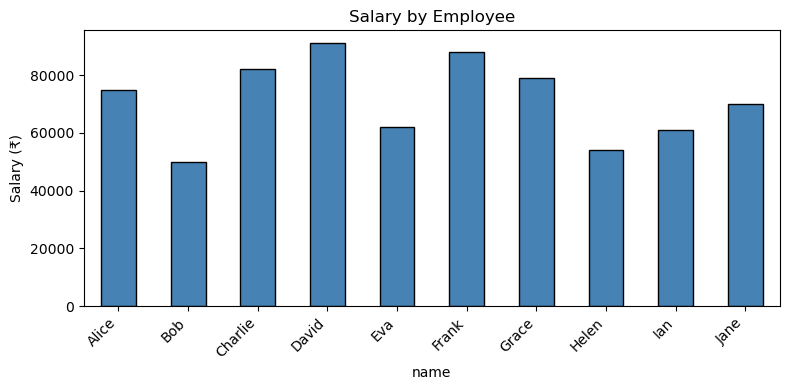

In [303]:
# ── Bar chart — salary by employee ───────────────────────────────────────
df.set_index('name')['salary'].plot(
    kind='bar',
    color='steelblue',
    edgecolor='black',
    title='Salary by Employee',
)
plt.ylabel('Salary (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

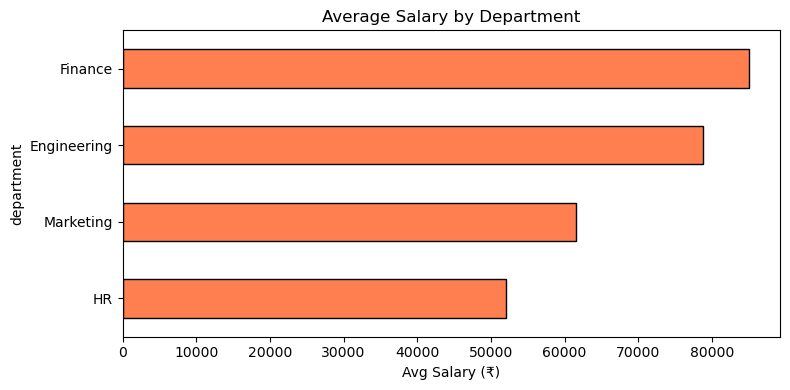

In [304]:
# ── Horizontal bar chart — avg salary by department ─────────────────────
df.groupby('department')['salary'].mean().sort_values().plot(
    kind='barh',
    color='coral',
    edgecolor='black',
    title='Average Salary by Department',
)
plt.xlabel('Avg Salary (₹)')
plt.tight_layout()
plt.show()

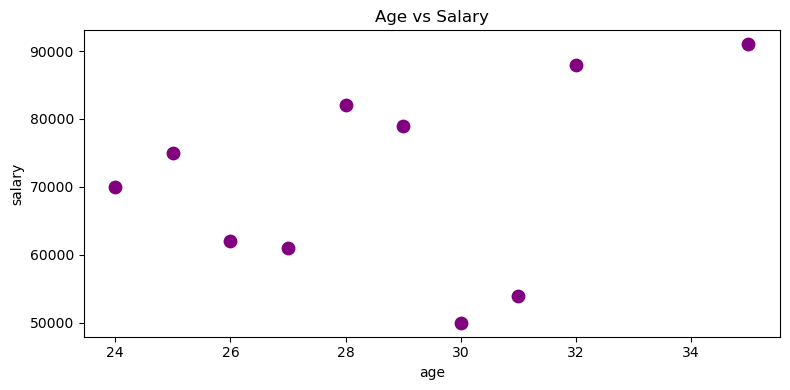

In [305]:
# ── Scatter plot — age vs salary ─────────────────────────────────────────
df.plot(
    kind='scatter',
    x='age',
    y='salary',
    color='purple',
    s=80,
    title='Age vs Salary',
)
plt.tight_layout()
plt.show()

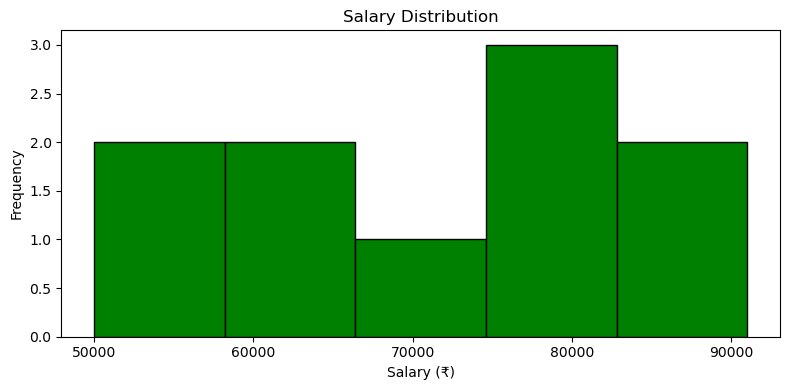

In [306]:
# ── Histogram — salary distribution ─────────────────────────────────────
df['salary'].plot(
    kind='hist',
    bins=5,
    color='green',
    edgecolor='black',
    title='Salary Distribution',
)
plt.xlabel('Salary (₹)')
plt.tight_layout()
plt.show()

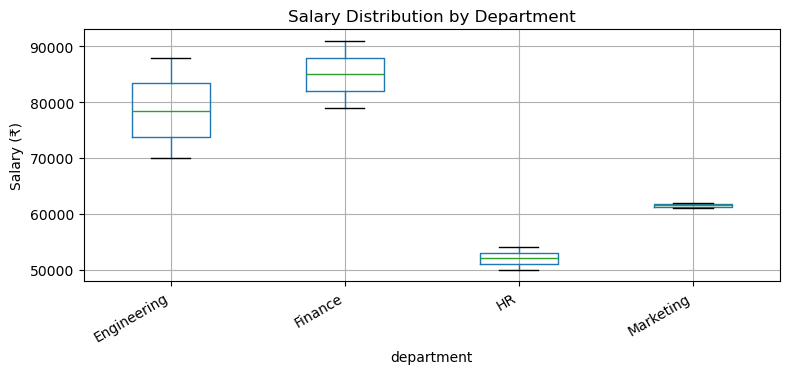

In [307]:
# ── Box plot — salary by department ──────────────────────────────────────
df.boxplot(
    column='salary',
    by='department',
)
plt.suptitle('')   # suppress auto title
plt.title('Salary Distribution by Department')
plt.ylabel('Salary (₹)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

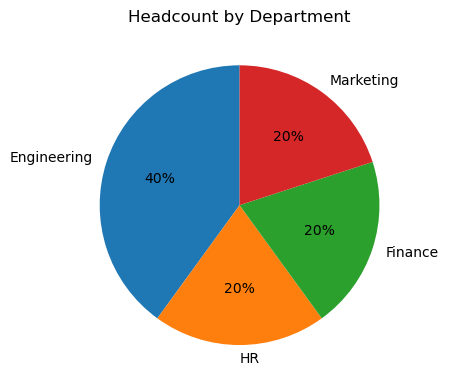

In [308]:
# ── Pie chart — headcount per department ─────────────────────────────────
df['department'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    startangle=90,
    title='Headcount by Department',
)
plt.ylabel('')     # hide default ylabel
plt.tight_layout()
plt.show()

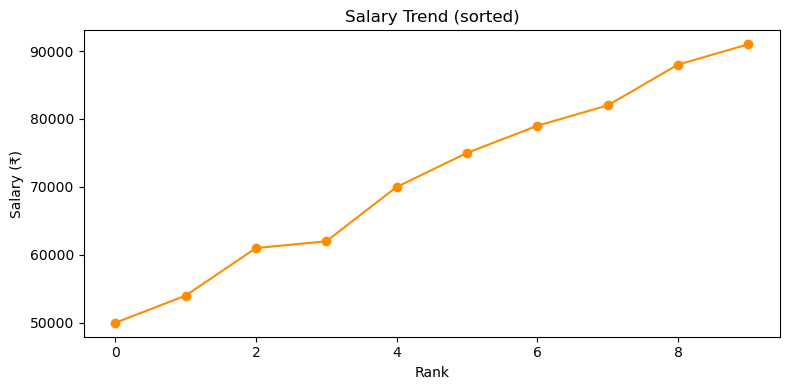

In [309]:
# ── Line chart — sorted salary trend ─────────────────────────────────────
df_sorted = df.sort_values('salary').reset_index(drop=True)
df_sorted['salary'].plot(
    kind='line',
    marker='o',
    color='darkorange',
    title='Salary Trend (sorted)',
)
plt.xlabel('Rank')
plt.ylabel('Salary (₹)')
plt.tight_layout()
plt.show()

---
## 18. Cheat-Sheet Quick Reference

### Reading & Writing
```python
pd.read_csv('file.csv')              # load CSV
pd.read_excel('file.xlsx')           # load Excel
df.to_csv('out.csv', index=False)    # save CSV
df.to_excel('out.xlsx', index=False) # save Excel
```

### Exploring
```python
df.shape          # (rows, cols)
df.head(n)        # first n rows
df.tail(n)        # last n rows
df.info()         # schema + non-null counts
df.describe()     # statistics
df.dtypes         # column types
df['col'].unique()            # unique values
df['col'].value_counts()      # frequency table
df.isnull().sum()             # missing per column
```

### Selecting
```python
df['col']                    # single column (Series)
df[['a','b']]                # multiple columns (DataFrame)
df.loc[row_label, col_label] # by label
df.iloc[row_pos, col_pos]    # by position
```

### Filtering
```python
df[df['col'] > 10]
df[(df['a'] > 5) & (df['b'] == 'x')]
df[df['col'].isin(['a','b'])]
df.query("age > 30 and department == 'HR'")
```

### Modifying
```python
df['new'] = df['a'] + df['b']         # add column
df.drop(columns=['col'])               # drop column
df.drop(index=0)                       # drop row
df.rename(columns={'old':'new'})       # rename
df.sort_values('col', ascending=False) # sort
df['col'].astype(float)               # cast type
df.assign(new=lambda x: x['a']*2)    # assign (chainable)
```

### Missing Values
```python
df.isnull().sum()         # count NaN per column
df.dropna()               # drop rows with any NaN
df.fillna(0)              # fill NaN with 0
df.fillna(df.mean())      # fill with column mean
df.ffill()                # forward fill
df.bfill()                # backward fill
df.interpolate()          # linear interpolation
```

### GroupBy
```python
df.groupby('col')['val'].mean()
df.groupby('col').agg(mean=('val','mean'), n=('val','count'))
df.groupby('col')['val'].transform('mean')   # keep original shape
```

### Merge / Join
```python
pd.concat([df1, df2], ignore_index=True)             # union rows
pd.merge(df1, df2, on='key', how='inner')            # inner join
pd.merge(df1, df2, left_on='a', right_on='b')        # different key names
```

### String Methods
```python
df['col'].str.upper()
df['col'].str.contains('pat', case=False)
df['col'].str.replace('old','new')
df['col'].str.split(',', expand=True)
df['col'].str.extract(r'(pattern)')
```

### Apply / Map
```python
df['col'].map({'a':1, 'b':2})          # map dict
df['col'].apply(func)                   # apply function
df.apply(func, axis=1)                  # apply row-wise
```

### Dates
```python
pd.to_datetime(df['col'])
df['col'].dt.year
df['col'].dt.month
df['col'].dt.day_name()
pd.date_range('2024-01-01', periods=12, freq='MS')
```

### Performance
```python
df['col'].astype('category')             # low-cardinality strings
pd.to_numeric(df['col'], downcast='integer')
df.memory_usage(deep=True)
subset = df[condition].copy()            # avoid SettingWithCopyWarning
```

In [310]:
print("✅ Pandas notebook complete!")
print("You have covered:")
topics = [
    "Series & DataFrame fundamentals",
    "Reading CSV / Excel / JSON",
    "Exploring DataFrames (head, info, describe, dtypes)",
    "Selecting with [], .loc, .iloc",
    "Filtering with boolean masks & .query()",
    "Adding/dropping/renaming columns",
    "Sorting, reindexing, type casting",
    "Handling missing values (NaN, fillna, ffill, interpolate)",
    "Aggregation with groupby & pivot_table",
    "Merging, joining & concatenating DataFrames",
    "String operations with .str accessor",
    "apply(), map() & lambda functions",
    "Reshaping with melt, pivot, stack/unstack",
    "Date & time with pd.to_datetime and .dt accessor",
    "MultiIndex DataFrames",
    "Categorical dtype & memory optimization",
    "Visualization: bar, scatter, hist, box, pie, line charts",
]
for i, t in enumerate(topics, 1):
    print(f"  {i:2d}. {t}")

✅ Pandas notebook complete!
You have covered:
   1. Series & DataFrame fundamentals
   2. Reading CSV / Excel / JSON
   3. Exploring DataFrames (head, info, describe, dtypes)
   4. Selecting with [], .loc, .iloc
   5. Filtering with boolean masks & .query()
   6. Adding/dropping/renaming columns
   7. Sorting, reindexing, type casting
   8. Handling missing values (NaN, fillna, ffill, interpolate)
   9. Aggregation with groupby & pivot_table
  10. Merging, joining & concatenating DataFrames
  11. String operations with .str accessor
  12. apply(), map() & lambda functions
  13. Reshaping with melt, pivot, stack/unstack
  14. Date & time with pd.to_datetime and .dt accessor
  15. MultiIndex DataFrames
  16. Categorical dtype & memory optimization
  17. Visualization: bar, scatter, hist, box, pie, line charts


---
## 19. LeetCode Patterns — Techniques for Both Study Plans

This section covers every technique tested across the **Introduction to Pandas (15 Qs)**  
and **30 Days of Pandas (32 Qs)** study plans — mapped to concrete problem types.

Each pattern includes: what it does, why it's needed, and a runnable example.


### Pattern A — `rank()` — Rank Scores, Nth Highest

**Problems:** Rank Scores, Second Highest Salary, Nth Highest Salary

`Series.rank()` assigns a rank to each value. The `method` parameter controls  
what happens when values are tied.


In [ ]:
import pandas as pd
import numpy as np
CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# ── rank() basics ─────────────────────────────────────────────────────────
scores = pd.Series([90, 85, 90, 78, 85, 100])

print("method='average'  (default):", scores.rank(method='average').tolist())
# ties get average of their ranks: 90s share ranks 3&4 → both get 3.5
print("method='min'               :", scores.rank(method='min').tolist())
# ties all get the lowest rank
print("method='dense'             :", scores.rank(method='dense').tolist())
# ties share same rank, NO gaps — this is what LeetCode 'Rank Scores' wants
print("method='first'             :", scores.rank(method='first').tolist())
# ties broken by first occurrence

print()
# Dense rank descending (highest score = rank 1)
print("Dense rank descending:")
df['salary_rank'] = df['salary'].rank(method='dense', ascending=False).astype(int)
print(df[['name','salary','salary_rank']].sort_values('salary_rank'))

print()
# ── Nth Highest Salary pattern ────────────────────────────────────────────
def nth_highest_salary(df, n):
    unique_sorted = df['salary'].drop_duplicates().sort_values(ascending=False)
    if len(unique_sorted) < n:
        return pd.DataFrame({'salary': [None]})   # not enough distinct salaries
    return pd.DataFrame({'salary': [unique_sorted.iloc[n - 1]]})

print("2nd highest salary:", nth_highest_salary(df, 2)['salary'].iloc[0])
print("3rd highest salary:", nth_highest_salary(df, 3)['salary'].iloc[0])
print("99th highest (None):", nth_highest_salary(df, 99)['salary'].iloc[0])


### Pattern B — `nlargest()` / `nsmallest()` — Top N Rows

**Problems:** Customer Placing Largest Number of Orders, Department Highest Salary

Faster and cleaner than `sort_values(...).head(n)` for getting top/bottom N rows.


In [ ]:
import pandas as pd
CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# Top 3 highest salaries
print("Top 3 salaries:")
print(df.nlargest(3, 'salary')[['name','salary']])

print()
# Bottom 3
print("Bottom 3 salaries:")
print(df.nsmallest(3, 'salary')[['name','salary']])

print()
# ── idxmax() / idxmin() — index of the row with max/min value ─────────────
idx_max = df['salary'].idxmax()   # row index label
idx_min = df['salary'].idxmin()

print(f"Highest earner: {df.loc[idx_max, 'name']} (₹{df.loc[idx_max, 'salary']})")
print(f"Lowest earner : {df.loc[idx_min, 'name']} (₹{df.loc[idx_min, 'salary']})")

print()
# ── groupby + idxmax — highest salary PER department ─────────────────────
idx_per_dept = df.groupby('department')['salary'].idxmax()
print("Highest earner per department:")
print(df.loc[idx_per_dept, ['department','name','salary']].set_index('department'))


### Pattern C — `size()` vs `count()` in groupby

**Problems:** Classes More Than 5 Students, Actors/Directors 3+ Cooperations

A critical distinction that causes bugs:
- `groupby().size()` — counts **all** rows in each group (including NaN)
- `groupby().count()` — counts **non-NaN** values per column

For most LeetCode counting problems, you want `size()` or `count()` on a specific column.


In [ ]:
import pandas as pd
import numpy as np
CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# ── size() — total rows per group ─────────────────────────────────────────
print("groupby().size() — employee count per department:")
dept_size = df.groupby('department').size()
print(dept_size)
print(type(dept_size))   # Series with MultiIndex if multiple groupby keys

print()
# Convert to DataFrame with reset_index()
dept_size_df = df.groupby('department').size().reset_index(name='headcount')
print(dept_size_df)

print()
# ── LeetCode pattern: keep groups with count >= threshold ─────────────────
# "Classes More Than 5 Students" — keep classes with ≥ 5 students
# Simulated: keep departments with ≥ 2 employees
large_depts = (df.groupby('department')
                 .size()
                 .reset_index(name='cnt')
                 .query('cnt >= 2')['department'])
print("Departments with 2+ employees:", large_depts.tolist())

print()
# ── Alternative: filter() on groups ───────────────────────────────────────
result = df.groupby('department').filter(lambda g: len(g) >= 2)
print("Employees in large departments:")
print(result[['name','department']])

print()
# ── count() vs size() with NaN ────────────────────────────────────────────
df_nan = pd.DataFrame({
    'dept': ['Eng', 'Eng', 'HR', 'HR'],
    'name': ['Alice', None, 'Bob', 'Grace']   # HR has one NaN name
})
print("size()  (counts NaN rows too):", df_nan.groupby('dept').size().to_dict())
print("count() (skips NaN)          :", df_nan.groupby('dept')['name'].count().to_dict())


### Pattern D — Anti-Join — "Customers Who Never Order"

**Problems:** Customers Who Never Order, Sales Person

An **anti-join** finds rows in table A that have **no match** in table B.  
SQL has `WHERE id NOT IN (...)`. In Pandas the pattern is: **left join + filter NaN**.


In [ ]:
import pandas as pd

# ── Setup: customers and orders ───────────────────────────────────────────
customers = pd.DataFrame({
    'id':   [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
})
orders = pd.DataFrame({
    'id':          [1, 1, 3],
    'customerId':  [2, 4, 2],   # Bob and David placed orders
    'amount':      [100, 200, 150],
})

print("Customers:"); print(customers)
print("
Orders:");   print(orders)

# ── Anti-join: customers who NEVER placed an order ─────────────────────────
# Step 1: left join — all customers, NaN where no matching order
merged = customers.merge(orders, left_on='id', right_on='customerId', how='left')
print("
After left join:")
print(merged)

# Step 2: filter rows where the order key is NaN (= no match in orders)
never_ordered = merged[merged['customerId'].isna()][['name']].rename(columns={'name': 'Customers'})
print("
Customers who never ordered:")
print(never_ordered)

print()
# ── Alternative: using isin() ─────────────────────────────────────────────
ordered_ids = orders['customerId'].unique()
never_ordered2 = customers[~customers['id'].isin(ordered_ids)][['name']]
print("Using isin() — same result:")
print(never_ordered2)


### Pattern E — `pd.cut()` — Binning / Salary Categories

**Problems:** Count Salary Categories

`pd.cut()` assigns numeric values to named bins (like "Low", "Mid", "High").  
`pd.qcut()` does the same but makes equal-sized bins based on quantiles.


In [ ]:
import pandas as pd
import numpy as np
CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# ── pd.cut() — fixed boundaries ─────────────────────────────────────────
df['salary_cat'] = pd.cut(
    df['salary'],
    bins   = [0, 60000, 80000, float('inf')],
    labels = ['Low', 'Average', 'High'],
    right  = True    # default: (low, high] — left exclusive, right inclusive
)
print(df[['name','salary','salary_cat']])

print()
# Count per category — LeetCode "Count Salary Categories" pattern
# Must include ALL categories even if count is 0
all_cats = pd.CategoricalIndex(['Low', 'Average', 'High'])
counts = (df['salary_cat']
          .value_counts()
          .reindex(all_cats, fill_value=0)
          .reset_index())
counts.columns = ['category', 'accounts_count']
print(counts)

print()
# ── pd.qcut() — quantile-based (equal-frequency) bins ───────────────────
df['salary_quartile'] = pd.qcut(df['salary'], q=4, labels=['Q1','Q2','Q3','Q4'])
print(df[['name','salary','salary_quartile']])

print()
# ── Alternative with np.where / np.select (also common) ──────────────────
conditions = [df['salary'] < 60000, df['salary'].between(60000, 80000)]
choices    = ['Low', 'Average']
df['salary_cat2'] = np.select(conditions, choices, default='High')
print(df[['name','salary','salary_cat2']])


### Pattern F — Advanced `groupby` Aggregations

**Problems:** Group Sold Products By Date, Daily Leads and Partners, Game Play Analysis I

These problems require non-standard aggregations like joining strings, counting unique values,  
and finding earliest/latest dates within a group.


In [ ]:
import pandas as pd
CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# ── String joining aggregation ─────────────────────────────────────────────
# "Group Sold Products By The Date" — list all products per date as a string
sales = pd.DataFrame({
    'sell_date': ['2020-07-01','2020-07-01','2020-07-02','2020-07-02','2020-07-02'],
    'product':   ['Banana','Apple','Avocado','Apple','Banana'],
})

result = (sales
    .groupby('sell_date')
    .agg(
        num_sold = ('product', 'nunique'),                      # unique count
        products = ('product', lambda x: ','.join(sorted(x.unique())))  # sorted joined string
    )
    .reset_index())
print("Group Sold Products By Date:")
print(result)

print()
# ── nunique — unique values in a group ────────────────────────────────────
# "Number of Unique Subjects Taught by Each Teacher"
teaching = pd.DataFrame({
    'teacher_id': [1, 1, 1, 2, 2],
    'subject_id': [2, 2, 3, 1, 2],   # teacher 1 taught subject 2 twice
    'dept_id':    [3, 4, 3, 1, 1],
})
result2 = (teaching
    .groupby('teacher_id')['subject_id']
    .nunique()
    .reset_index(name='cnt'))
print("Unique subjects per teacher:")
print(result2)

print()
# ── min() in groupby — first login date (Game Play Analysis I) ────────────
activity = pd.DataFrame({
    'player_id': [1, 1, 2, 3, 3],
    'device_id': [2, 2, 3, 1, 4],
    'event_date': pd.to_datetime(['2016-03-01','2016-05-02','2017-06-25','2016-03-02','2018-07-03']),
    'games_played': [5, 6, 1, 0, 5],
})
first_login = (activity
    .groupby('player_id')['event_date']
    .min()
    .reset_index()
    .rename(columns={'event_date': 'first_login'}))
print("First login per player:")
print(first_login)

print()
# ── size() chain — actors/directors >= 3 cooperations ─────────────────────
actor_dir = pd.DataFrame({
    'actor_id':    [1, 1, 1, 1, 2],
    'director_id': [4, 4, 4, 3, 4],
    'timestamp':   [0, 1, 2, 3, 4],
})
result3 = (actor_dir
    .groupby(['actor_id','director_id'])
    .size()
    .reset_index(name='count')
    .query('count >= 3')
    [['actor_id','director_id']])
print("Actor-Director pairs with 3+ cooperations:")
print(result3)


### Pattern G — Self-Join and Cross Join

**Problems:** Managers with ≥5 Direct Reports (self-join), Students and Examinations (cross join)

**Self-join:** merge a DataFrame with itself to compare rows against each other.  
**Cross join:** every row of A paired with every row of B (`how='cross'`).


In [ ]:
import pandas as pd

# ── Self-join: Managers with >= 5 Direct Reports ───────────────────────────
employees = pd.DataFrame({
    'id':         [101, 102, 103, 104, 105, 106, 107],
    'name':       ['Alice','Bob','Charlie','David','Eva','Frank','Grace'],
    'managerId':  [None, 101, 101, 101, 101, 101, 102],  # Alice manages 5 people
})
employees['managerId'] = employees['managerId'].astype('Int64')  # nullable int

# Join employees to itself: find how many reports each manager has
direct_reports = (employees
    .groupby('managerId')
    .size()
    .reset_index(name='report_count')
    .rename(columns={'managerId': 'id'}))

# Managers with >= 5 direct reports
result = (employees
    .merge(direct_reports, on='id')
    .query('report_count >= 5')
    [['name']])
print("Managers with 5+ direct reports:")
print(result)

print()
# ── Cross join: Students and Examinations ──────────────────────────────────
# Every student should appear with every subject — even if no exam taken
students = pd.DataFrame({'student_id':[1,2,3], 'student_name':['Alice','Bob','Charlie']})
subjects = pd.DataFrame({'subject_name':['Math','Physics','Chemistry']})

# Cross join: 3 students × 3 subjects = 9 rows
cross = students.merge(subjects, how='cross')
print("Cross join (all student-subject combos):")
print(cross)

print()
# Then left join exam attendance, fill missing with 0
exams = pd.DataFrame({
    'student_id':   [1, 1, 2],
    'subject_name': ['Math','Physics','Math'],
})
result2 = (cross
    .merge(exams, on=['student_id','subject_name'], how='left')
    .assign(attended_exams = lambda x: x.groupby(['student_id','subject_name'])
                                         ['subject_name'].transform('count').fillna(0).astype(int))
    .drop_duplicates(subset=['student_id','subject_name'])
    .sort_values(['student_id','subject_name'])
    .reset_index(drop=True))

# Simpler approach for the count
exam_counts = exams.groupby(['student_id','subject_name']).size().reset_index(name='attended_exams')
final = (cross
    .merge(exam_counts, on=['student_id','subject_name'], how='left')
    .fillna({'attended_exams': 0})
    .assign(attended_exams = lambda x: x['attended_exams'].astype(int))
    .sort_values(['student_id','subject_name'])
    .reset_index(drop=True))
print("Students and Examinations result:")
print(final)


### Pattern H — Boolean Percentage / Fraction

**Problems:** Immediate Food Delivery I, Count Salary Categories

A boolean Series (`True`/`False`) can be treated as `1`/`0`.  
`.mean()` on a boolean Series gives you the **fraction** of True values.


In [ ]:
import pandas as pd

# ── Immediate Food Delivery I ─────────────────────────────────────────────
# "What % of first orders were delivered immediately (order date == preferred date)?"

delivery = pd.DataFrame({
    'delivery_id':          [1, 2, 3, 4, 5],
    'customer_id':          [1, 2, 1, 3, 3],
    'order_date':           pd.to_datetime(['2019-08-01','2019-08-02','2019-08-11','2019-08-24','2019-08-21']),
    'customer_pref_date':   pd.to_datetime(['2019-08-02','2019-08-02','2019-08-12','2019-08-26','2019-08-22']),
})

# First order per customer
first_orders = delivery.groupby('customer_id')['order_date'].idxmin()
first_df = delivery.loc[first_orders]

# Immediate = order date == preferred date
immediate_pct = round((first_df['order_date'] == first_df['customer_pref_date']).mean() * 100, 2)
print(f"Immediate delivery %: {immediate_pct}%")

print()
# ── The pattern generally ─────────────────────────────────────────────────
df = pd.DataFrame({'score': [85, 92, 45, 78, 95, 38]})

# How many are above 80? (count)
above_80_count = (df['score'] > 80).sum()

# What fraction are above 80?
above_80_pct = round((df['score'] > 80).mean() * 100, 1)

print(f"Scores above 80: {above_80_count} out of {len(df)} ({above_80_pct}%)")


### Pattern I — Output Format, Column Selection & Ordering

LeetCode problems always specify:
- **which columns** to return
- **which column to sort by** and in what direction

These patterns come up in almost every single problem.


In [ ]:
import pandas as pd
CSV_PATH = "sample.csv"
df = pd.read_csv(CSV_PATH)

# ── Select specific columns in a specific order ───────────────────────────
# LeetCode: "return the result table with columns [name, salary] sorted by salary desc"

result = (df[['name', 'salary']]          # select only these two columns
            .sort_values('salary',
                         ascending=False)  # sort by salary descending
            .reset_index(drop=True))       # reset index to 0,1,2,...
print(result)

print()
# ── sort by multiple columns ─────────────────────────────────────────────
# "sort by department asc, then by name asc"
result2 = (df[['name','department','salary']]
             .sort_values(['department','name'], ascending=[True, True])
             .reset_index(drop=True))
print(result2)

print()
# ── Rename columns in the result ─────────────────────────────────────────
# LeetCode often wants specific column names in the output
result3 = (df.groupby('department')['salary']
             .mean()
             .reset_index()
             .rename(columns={'salary': 'average_salary'})
             .round({'average_salary': 2}))
print(result3)

print()
# ── to_frame() — convert Series back to DataFrame ─────────────────────────
# groupby().agg() sometimes returns a Series; to_frame() makes it a DataFrame
s = df.groupby('department')['salary'].mean()
print(type(s))           # Series
df_result = s.to_frame(name='avg_salary').reset_index()
print(df_result)

print()
# ── Returning None / empty DataFrame when answer doesn't exist ───────────
# "Second highest salary — return null if it doesn't exist"
def second_highest(df):
    unique = df['salary'].drop_duplicates().sort_values(ascending=False)
    if len(unique) < 2:
        return pd.DataFrame({'SecondHighestSalary': [None]})
    return pd.DataFrame({'SecondHighestSalary': [unique.iloc[1]]})

print(second_highest(df))
print(second_highest(df.head(1)))  # only 1 unique salary


### Pattern J — Complete Walkthrough: Intro to Pandas (15 Problems)

These are the exact patterns used in the 15-question Introduction to Pandas study plan.  
Each solution is in the form LeetCode expects: a function that returns a DataFrame.


In [ ]:
import pandas as pd
import numpy as np

# ── 2877: Create a DataFrame from List ────────────────────────────────────
def createDataframe(student_data):
    # student_data is a 2D list: [[id, age], [id, age], ...]
    return pd.DataFrame(student_data, columns=['student_id', 'age'])

print(createDataframe([[1,15],[2,11],[3,20]]))

print()
# ── 2878: Get the Size of a DataFrame ────────────────────────────────────
def getDataframeSize(players):
    return [players.shape[0], players.shape[1]]  # [rows, columns]

sample = pd.DataFrame({'a':[1,2,3],'b':[4,5,6]})
print("Size:", getDataframeSize(sample))

print()
# ── 2879: Display the First Three Rows ───────────────────────────────────
def selectFirstRows(employees):
    return employees.head(3)

print()
# ── 2880: Select Data ─────────────────────────────────────────────────────
def selectData(students):
    # Return name and age of student_id == 101
    return students.loc[students['student_id'] == 101, ['name', 'age']]

students = pd.DataFrame({'student_id':[101,102,103],'name':['Alice','Bob','Charlie'],'age':[20,21,19]})
print(selectData(students))

print()
# ── 2881: Create a New Column ─────────────────────────────────────────────
def createBonusColumn(employees):
    employees['bonus'] = employees['salary'] * 2
    return employees

emp = pd.DataFrame({'name':['Alice','Bob'],'salary':[5000,6000]})
print(createBonusColumn(emp))

print()
# ── Drop Duplicate Rows ───────────────────────────────────────────────────
def dropDuplicateEmails(customers):
    return customers.drop_duplicates(subset=['email'])

cust = pd.DataFrame({'customer_id':[1,2,3],'name':['Alice','Bob','Alice'],
                     'email':['a@x.com','b@x.com','a@x.com']})
print(dropDuplicateEmails(cust))

print()
# ── Drop Missing Data ─────────────────────────────────────────────────────
def dropMissingData(students):
    return students.dropna(subset=['name'])   # drop rows where name is NaN

s2 = pd.DataFrame({'student_id':[1,2,3],'name':['Alice',None,'Charlie'],'age':[20,21,19]})
print(dropMissingData(s2))

print()
# ── Modify Columns ────────────────────────────────────────────────────────
def modifySalaryColumn(employees):
    employees['salary'] = employees['salary'] * 2
    return employees

print()
# ── Rename Columns ────────────────────────────────────────────────────────
def renameColumns(students):
    return students.rename(columns={
        'id': 'student_id', 'first': 'first_name',
        'last': 'last_name', 'age': 'age_in_years'
    })

print()
# ── Change Data Type ──────────────────────────────────────────────────────
def changeDatatype(students):
    students['grade'] = students['grade'].astype(int)
    return students

print()
# ── Fill Missing Values ───────────────────────────────────────────────────
def fillMissingValues(products):
    products['quantity'] = products['quantity'].fillna(0)
    return products

print()
# ── Reshape Data (Concatenate) ────────────────────────────────────────────
def concatenateTables(df1, df2):
    return pd.concat([df1, df2], ignore_index=True)

a = pd.DataFrame({'student_id':[1,2],'name':['Alice','Bob'],'age':[20,21]})
b = pd.DataFrame({'student_id':[3,4],'name':['Charlie','David'],'age':[22,23]})
print(concatenateTables(a, b))


### Pattern K — Complete Walkthrough: 30 Days of Pandas — Key Problems

One representative solution per category from the 30 Days plan.


In [ ]:
import pandas as pd
import numpy as np

# ══ DATA FILTERING ══════════════════════════════════════════════════════════

# Big Countries: area >= 3,000,000 OR population >= 25,000,000
def bigCountries(world):
    mask = (world['area'] >= 3_000_000) | (world['population'] >= 25_000_000)
    return world.loc[mask, ['name','population','area']]

# Recyclable AND Low Fat Products
def findProducts(products):
    return products.loc[
        (products['low_fats'] == 'Y') & (products['recyclable'] == 'Y'),
        ['product_id']
    ]

# Customers Who Never Ordered (anti-join)
def findCustomers(customers, orders):
    merged = customers.merge(orders, left_on='id', right_on='customerId', how='left')
    return (merged[merged['customerId'].isna()]
            [['name']]
            .rename(columns={'name': 'Customers'}))

# Article Views I: find authors who viewed their OWN article, sort & deduplicate
def articleViews(views):
    return (views[views['author_id'] == views['viewer_id']]
            [['author_id']]
            .rename(columns={'author_id': 'id'})
            .drop_duplicates()
            .sort_values('id')
            .reset_index(drop=True))

print("Anti-join example:")
customers = pd.DataFrame({'id':[1,2,3,4],'name':['Alice','Bob','Charlie','David']})
orders    = pd.DataFrame({'orderId':[1,2],'customerId':[2,4],'amount':[100,200]})
print(findCustomers(customers, orders))

print()
# ══ STRING METHODS ════════════════════════════════════════════════════════════

# Invalid Tweets: content length > 15
def invalidTweets(tweets):
    return tweets.loc[tweets['content'].str.len() > 15, ['tweet_id']]

# Fix Names: capitalize name column
def fixNames(users):
    users['name'] = users['name'].str.capitalize()
    return users.sort_values('user_id')

# Find Valid Emails: starts with letter, allowed chars, @leetcode.com
def validEmails(users):
    pattern = r'^[A-Za-z][A-Za-z0-9_.-]*@leetcode\.com$'
    return users[users['mail'].str.match(pattern)]

# Calculate Special Bonus: odd id AND name not starting with 'M' → bonus = salary; else 0
def calculateSpecialBonus(employees):
    employees['bonus'] = np.where(
        (employees['employee_id'] % 2 == 1) & (~employees['name'].str.startswith('M')),
        employees['salary'], 0
    )
    return employees[['employee_id','bonus']].sort_values('employee_id')

emp = pd.DataFrame({
    'employee_id':[2,3,7,8,9],
    'name':['Alice','Bob','Megan','Dan','Maria'],
    'salary':[9000,6000,3000,7400,6000]
})
print("Special Bonus:")
print(calculateSpecialBonus(emp))

print()
# ══ DATA MANIPULATION ════════════════════════════════════════════════════════

# Rank Scores — dense rank descending
def orderScores(scores):
    scores['rank'] = scores['score'].rank(method='dense', ascending=False).astype(int)
    return scores[['score','rank']].sort_values('score', ascending=False).reset_index(drop=True)

sc = pd.DataFrame({'id':[1,2,3,4,5,6],'score':[3.50,3.65,4.00,3.85,4.00,3.65]})
print("Rank Scores:"); print(orderScores(sc))

print()
# Delete Duplicate Emails — keep lowest id per email
def deleteEmails(person):
    return (person.sort_values('id')
                  .drop_duplicates(subset=['email'], keep='first')
                  .reset_index(drop=True))

# Rearrange Products Table — melt
def rearrangeProductsTable(products):
    return products.melt(
        id_vars    = ['product_id'],
        value_vars = ['store1','store2','store3'],
        var_name   = 'store',
        value_name = 'price'
    ).dropna(subset=['price'])

p = pd.DataFrame({'product_id':[0,1],'store1':[95,70],'store2':[None,67],'store3':[105,None]})
print("Rearrange Products:"); print(rearrangeProductsTable(p))

print()
# ══ STATISTICS ════════════════════════════════════════════════════════════════

# The Number of Rich Customers: count(distinct customer_id where amount > 500)
def countRichCustomers(store):
    return pd.DataFrame({'rich_count': [store[store['amount'] > 500]['customer_id'].nunique()]})

# Immediate Food Delivery (% of first orders that are immediate)
def foodDelivery(delivery):
    first_orders = delivery.loc[delivery.groupby('customer_id')['order_date'].idxmin()]
    immediate = (first_orders['order_date'] == first_orders['customer_pref_delivery_date']).mean()
    return pd.DataFrame({'immediate_percentage': [round(immediate * 100, 2)]})

# Count Salary Categories
def countSalaryCategories(accounts):
    low    = (accounts['income'] < 20000).sum()
    avg    = accounts['income'].between(20000, 50000).sum()
    high   = (accounts['income'] > 50000).sum()
    return pd.DataFrame({
        'category': ['Low Salary','Average Salary','High Salary'],
        'accounts_count': [low, avg, high]
    })

ac = pd.DataFrame({'account_id':[3,2,8,6],'income':[108939,12747,87709,91796]})
print("Salary Categories:"); print(countSalaryCategories(ac))


In [ ]:
import pandas as pd
import numpy as np

# ══ DATA AGGREGATION ══════════════════════════════════════════════════════════

# Find Total Time Spent by Each Employee
def totalTime(employees):
    return (employees.assign(total_time = employees['out_time'] - employees['in_time'])
                     .groupby(['emp_id','event_day'], as_index=False)['total_time']
                     .sum()
                     .rename(columns={'event_day':'day'}))

# Game Play Analysis I: first login per player
def gamePlayAnalysis(activity):
    return (activity.groupby('player_id')['event_date']
                    .min()
                    .reset_index()
                    .rename(columns={'event_date':'first_login'}))

# Number of Unique Subjects per Teacher
def uniqueSubjectsPerTeacher(teacher):
    return (teacher.groupby('teacher_id')['subject_id']
                   .nunique()
                   .reset_index(name='cnt'))

# Classes More Than 5 Students
def classesMoreThan5Students(courses):
    return (courses.groupby('class')
                   .size()
                   .reset_index(name='count')
                   .query('count >= 5')
                   [['class']])

# Customer Placing Largest Number of Orders
def largestOrders(orders):
    return (orders.groupby('customer_number')
                  .size()
                  .idxmax())   # returns the customer_number with most orders

# Group Sold Products By Date
def groupSoldProducts(activities):
    return (activities.groupby('sell_date')
                      .agg(num_sold=('product','nunique'),
                           products=('product', lambda x: ','.join(sorted(x.unique()))))
                      .reset_index())

sold = pd.DataFrame({
    'sell_date': ['2020-07-01','2020-07-01','2020-07-02','2020-07-02'],
    'product':   ['Banana','Apple','Banana','Apple']
})
print("Group Sold Products:")
print(groupSoldProducts(sold))

print()
# Daily Leads and Partners
def dailyLeadsAndPartners(dailySales):
    return (dailySales.groupby(['date_id','make_name'])
                      .agg(unique_leads=('lead_id','nunique'),
                           unique_partners=('partner_id','nunique'))
                      .reset_index())

# ══ DATA INTEGRATION ═════════════════════════════════════════════════════════

# Actors and Directors Cooperated at Least 3 Times
def actorDirectorCooperation(actorDirector):
    return (actorDirector.groupby(['actor_id','director_id'])
                         .size()
                         .reset_index(name='count')
                         .query('count >= 3')
                         [['actor_id','director_id']])

# Replace Employee ID with Unique Identifier (left join)
def replaceEmployeeId(employees, employeeUNI):
    return employees.merge(employeeUNI, on='id', how='left')[['unique_id','name']]

emp = pd.DataFrame({'id':[1,2,3],'name':['Alice','Bob','Charlie']})
uni = pd.DataFrame({'id':[3,1],'unique_id':[101,102]})
print("Replace Employee ID:")
print(replaceEmployeeId(emp, uni))

print()
# Managers with at Least 5 Direct Reports (self-join)
def managersWithFiveReports(employee):
    reports = (employee.groupby('managerId')
                       .size()
                       .reset_index(name='count')
                       .query('count >= 5')
                       .rename(columns={'managerId':'id'}))
    return employee.merge(reports, on='id')[['name']]

# Sales Person: sales persons who have NO orders with company 'RED' (anti-join)
def salesPerson(salesperson, company, orders):
    red_orders = orders[orders['com_id'].isin(company[company['name'] == 'RED']['com_id'])]
    worked_with_red = red_orders['sales_id'].unique()
    return salesperson[~salesperson['sales_id'].isin(worked_with_red)][['name']]

print("All 30 Days of Pandas patterns covered!")


---
# 📖 Appendix — Complete Pandas API Reference

Every function, method, and accessor used in this notebook — all parameters,  
types, defaults, and descriptions in one place.

Jump to a section:
- [A. Top-level `pd.*` functions](#A)
- [B. I/O — Reading & Writing](#B)
- [C. DataFrame Inspection](#C)
- [D. Selection & Filtering](#D)
- [E. Modifying DataFrames](#F)
- [F. Missing Values](#G)
- [G. Deduplication](#H)
- [H. Aggregation & Statistics](#I)
- [I. GroupBy](#J)
- [J. Reshaping](#K)
- [K. Merging, Joining & Concatenating](#L)
- [L. Apply, Map & Transform](#M)
- [M. String Methods `.str.*`](#N)
- [N. DateTime Methods `.dt.*`](#O)
- [O. Window & Cumulative](#P)
- [P. Type Conversion](#Q)
- [Q. Sorting & Ranking](#R)
- [R. Visualization](#S)


---
## A. Top-level `pd.*` Functions

### `pd.DataFrame()`
Creates a DataFrame from various input types.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `data` | dict, list, ndarray, Series, DataFrame | — | Input data. Dict keys become column names; list-of-lists becomes rows |
| `index` | array-like | RangeIndex | Row labels |
| `columns` | array-like | inferred | Column labels. Required when `data` is a list-of-lists |
| `dtype` | dtype | inferred | Force all columns to this dtype |
| `copy` | bool | `False` | Copy data from inputs |

```python
pd.DataFrame({'a': [1,2], 'b': [3,4]})           # from dict
pd.DataFrame([[1,2],[3,4]], columns=['a','b'])     # from list of lists
pd.DataFrame(np.zeros((3,2)), columns=['x','y'])  # from ndarray
```

---
### `pd.Series()`
Creates a 1-D labelled array.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `data` | array-like, dict, scalar | — | Values |
| `index` | array-like | RangeIndex | Row labels. If `data` is a dict, keys become index |
| `dtype` | dtype | inferred | Force a dtype |
| `name` | str | `None` | Name of the Series. Series name becomes column name when used in a DataFrame |
| `copy` | bool | `False` | Copy input data |

---
### `pd.concat()`
Stack DataFrames along rows or columns.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `objs` | list of DataFrames/Series | — | Objects to concatenate |
| `axis` | `0` or `1` | `0` | `0` = stack rows (more rows); `1` = stack columns (more columns) |
| `join` | `'inner'` or `'outer'` | `'outer'` | `'outer'` keeps all columns; `'inner'` keeps only shared columns |
| `ignore_index` | bool | `False` | If `True`, reset index to 0,1,2,… instead of keeping original labels |
| `keys` | list | `None` | Create a MultiIndex with these labels on the outer level |
| `sort` | bool | `False` | Sort non-concatenation axis if not aligned |
| `verify_integrity` | bool | `False` | Raise if resulting index has duplicates |

---
### `pd.merge()`
Join two DataFrames on a key column — like SQL JOIN.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `left` | DataFrame | — | Left DataFrame |
| `right` | DataFrame | — | Right DataFrame |
| `how` | `'inner'` `'left'` `'right'` `'outer'` `'cross'` | `'inner'` | Join type. `'cross'` = cartesian product (every row × every row) |
| `on` | str or list | `None` | Column(s) in both DataFrames to join on. Must have same name |
| `left_on` | str or list | `None` | Key column(s) from the left DataFrame when names differ |
| `right_on` | str or list | `None` | Key column(s) from the right DataFrame when names differ |
| `left_index` | bool | `False` | Use left DataFrame's index as the join key |
| `right_index` | bool | `False` | Use right DataFrame's index as the join key |
| `suffixes` | tuple of str | `('_x','_y')` | Suffixes to add to overlapping column names |
| `indicator` | bool or str | `False` | Add a `_merge` column showing source (`'left_only'`, `'right_only'`, `'both'`) |
| `validate` | str | `None` | Checks: `'1:1'`, `'1:m'`, `'m:1'`, `'m:m'` |

---
### `pd.to_datetime()`
Convert strings, ints, or other formats to datetime.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `arg` | str, list, Series, DataFrame | — | Data to convert |
| `format` | str | `None` | strptime format string e.g. `'%Y-%m-%d'`. Speeds up parsing when specified |
| `errors` | `'raise'` `'coerce'` `'ignore'` | `'raise'` | `'coerce'` turns unparseable values into `NaT` instead of raising |
| `dayfirst` | bool | `False` | If `True`, `01/02/03` is parsed as 1 Feb 2003 |
| `yearfirst` | bool | `False` | If `True`, `01/02/03` is parsed as 2001 Feb 3 |
| `utc` | bool | `False` | Return UTC DatetimeIndex |
| `unit` | str | `None` | Unit for integer input: `'s'` (seconds), `'ms'`, `'us'`, `'ns'` |

---
### `pd.to_numeric()`
Convert a Series to a numeric dtype.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `arg` | scalar, list, Series | — | Data to convert |
| `errors` | `'raise'` `'coerce'` `'ignore'` | `'raise'` | `'coerce'` turns non-numeric values into `NaN` |
| `downcast` | `None` `'integer'` `'signed'` `'unsigned'` `'float'` | `None` | Try to reduce memory by downcasting |

---
### `pd.cut()`
Bin continuous values into discrete categories with fixed boundaries.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `x` | array-like | — | Input data to bin |
| `bins` | int or list | — | Number of equal-width bins, or explicit bin edges like `[0, 30, 60, inf]` |
| `labels` | list or `False` | `None` | Names for the resulting bins. Must be length `len(bins)-1` |
| `right` | bool | `True` | If `True`, intervals are `(a, b]`; if `False`, `[a, b)` |
| `include_lowest` | bool | `False` | If `True`, leftmost interval is `[a, b]` (closed on both sides) |
| `retbins` | bool | `False` | If `True`, also return the computed bin edges |
| `precision` | int | `3` | Decimal precision for bin labels |
| `ordered` | bool | `True` | Whether resulting Categorical is ordered |

---
### `pd.qcut()`
Bin values into equal-frequency (quantile-based) buckets.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `x` | array-like | — | Input data |
| `q` | int or list of floats | — | Number of quantiles, or list of probabilities e.g. `[0, .25, .5, .75, 1]` |
| `labels` | list or `False` | `None` | Bin names |
| `retbins` | bool | `False` | Return the computed bin edges |
| `precision` | int | `3` | Label precision |
| `duplicates` | `'raise'` `'drop'` | `'raise'` | How to handle non-unique bin edges |

---
### `pd.date_range()`
Generate a fixed-frequency sequence of dates.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `start` | str or datetime | — | Left bound of the range |
| `end` | str or datetime | — | Right bound of the range |
| `periods` | int | `None` | Number of periods to generate. Specify 2 of {`start`, `end`, `periods`} |
| `freq` | str | `'D'` | Frequency: `'D'`=daily, `'B'`=business day, `'W'`=weekly, `'ME'`=month end, `'H'`=hourly |
| `tz` | str or tzinfo | `None` | Timezone for the result |

---
### `pd.pivot_table()`
Spreadsheet-style pivot table — group and aggregate in one step.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `data` | DataFrame | — | Source DataFrame |
| `values` | str or list | — | Column(s) to aggregate |
| `index` | str or list | — | Column(s) to become row labels |
| `columns` | str or list | `None` | Column(s) to become column labels (spread across top) |
| `aggfunc` | function or dict | `'mean'` | Aggregation function: `'sum'`, `'count'`, `np.mean`, etc. |
| `fill_value` | scalar | `None` | Fill missing cells with this value |
| `margins` | bool | `False` | Add row/column totals |
| `margins_name` | str | `'All'` | Name for the totals row/column |
| `dropna` | bool | `True` | Drop columns where all entries are NaN |

---
### `pd.crosstab()`
Cross-tabulation — frequency table between two or more categorical columns.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `index` | array-like, Series, list | — | Values for the rows |
| `columns` | array-like, Series, list | — | Values for the columns |
| `values` | array-like | `None` | Array of values to aggregate. Required if `aggfunc` is set |
| `aggfunc` | function | `None` | Aggregation function for `values` |
| `rownames` | list | `None` | Names for the row labels |
| `colnames` | list | `None` | Names for the column labels |
| `margins` | bool | `False` | Add row/column totals |
| `normalize` | bool or `'index'` or `'columns'` or `'all'` | `False` | Normalize by dividing each value by sum |

---
### `pd.isna()` / `pd.notna()`
Check for missing values element-wise. Return same-shape boolean result.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `obj` | scalar, array-like, Series, DataFrame | — | Object to check |

> `pd.isna()` is identical to `pd.isnull()`. `pd.notna()` is identical to `pd.notnull()`.


---
## B. I/O — Reading & Writing

### `pd.read_csv()`
Read a comma-separated values file into a DataFrame.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `filepath_or_buffer` | str, path, URL | — | File path, URL, or file-like object |
| `sep` / `delimiter` | str | `','` | Delimiter. Use `sep='	'` for TSV files |
| `header` | int or list | `'infer'` | Row number(s) to use as column names. `header=None` if no header row |
| `names` | list | `None` | Custom column names. Use with `header=0` to rename |
| `index_col` | int, str, False | `None` | Column to use as the row index |
| `usecols` | list or callable | `None` | Read only these columns (faster than reading all then dropping) |
| `dtype` | dict or dtype | `None` | Force specific dtypes e.g. `{'id': str, 'price': float}` |
| `nrows` | int | `None` | Read only the first N rows |
| `skiprows` | int or list | `None` | Skip these row numbers at start of file |
| `skipfooter` | int | `0` | Skip this many rows at the end of file |
| `na_values` | list or dict | `None` | Additional strings to treat as NaN |
| `keep_default_na` | bool | `True` | Include default NaN strings (empty, NA, NaN, NULL, etc.) |
| `parse_dates` | bool or list | `False` | Parse these columns as dates |
| `encoding` | str | `None` | File encoding e.g. `'utf-8'`, `'latin-1'` |
| `chunksize` | int | `None` | Return an iterator, reading `chunksize` rows at a time |
| `compression` | str | `'infer'` | `'gzip'`, `'zip'`, `'bz2'`, `'zstd'`, or `'infer'` from file extension |
| `thousands` | str | `None` | Thousands separator e.g. `','` for `1,000` |
| `decimal` | str | `'.'` | Decimal point character |
| `comment` | str | `None` | Lines starting with this character are skipped |
| `low_memory` | bool | `True` | Process in chunks; may infer mixed dtypes incorrectly on large files |

---
### `pd.read_excel()`
Read an Excel file (`.xlsx`, `.xls`).

| Parameter | Type | Default | Description |
|---|---|---|---|
| `io` | str, path, file | — | Path or URL to the Excel file |
| `sheet_name` | str, int, list, or `None` | `0` | Sheet to read. `0`=first sheet, `None`=all sheets (returns dict) |
| `header` | int or list | `0` | Row for column names |
| `names` | list | `None` | Custom column names |
| `index_col` | int, str | `None` | Column to use as index |
| `usecols` | str, list | `None` | Columns to read. Excel range `'A:D'` or list `[0, 2, 4]` |
| `dtype` | dict or dtype | `None` | Force dtypes |
| `na_values` | list | `None` | Extra NaN strings |
| `nrows` | int | `None` | Read only first N rows |
| `skiprows` | list | `None` | Skip these rows |

---
### `pd.read_json()` / `pd.read_parquet()` / `pd.read_sql()` / `pd.read_html()`

| Function | Key Parameters | Notes |
|---|---|---|
| `pd.read_json(path, orient, lines)` | `orient`: `'records'` `'index'` `'columns'` `'values'`; `lines=True` for JSON-lines format | |
| `pd.read_parquet(path, columns, engine)` | `columns`: list of cols to read; `engine`: `'pyarrow'` or `'fastparquet'` | Fastest format for large data |
| `pd.read_sql(sql, con, index_col, params)` | `sql`: query string or table name; `con`: SQLAlchemy engine or DBAPI2 connection | |
| `pd.read_html(url, match, header, index_col)` | `match`: regex/string to find the right table on a page | Returns a **list** of DataFrames |
| `pd.read_clipboard(sep)` | `sep`: delimiter string | Reads from your clipboard |

---
### `df.to_csv()`
Write DataFrame to a CSV file.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `path_or_buf` | str, path | `None` | File path. `None` returns the CSV as a string |
| `sep` | str | `','` | Delimiter |
| `na_rep` | str | `''` | String to write in place of NaN |
| `columns` | list | `None` | Write only these columns |
| `header` | bool or list | `True` | Write column names. `False` to omit |
| `index` | bool | `True` | Write row index. Usually set to `False` |
| `encoding` | str | `None` | File encoding |
| `date_format` | str | `None` | Format string for datetime values |
| `mode` | str | `'w'` | File open mode: `'w'`=overwrite (default); `'a'`=append to existing file |
| `compression` | str | `'infer'` | Compress output |
| `float_format` | str | `None` | Format floats e.g. `'%.2f'` |

---
### `df.to_excel()` / `df.to_json()` / `df.to_parquet()`

| Method | Key Parameters |
|---|---|
| `df.to_excel(path, sheet_name, index, startrow, startcol, engine)` | `sheet_name`: name of the sheet; `index=False` to omit index |
| `df.to_json(path, orient, lines, indent, date_format)` | `orient`: `'records'` `'index'` `'columns'` `'values'` `'table'`; `lines=True` for JSON-lines |
| `df.to_parquet(path, engine, compression, index)` | `compression`: `'snappy'` (default) `'gzip'` `'brotli'` |


---
## C. DataFrame Inspection

### `df.head()` / `df.tail()`
| Parameter | Type | Default | Description |
|---|---|---|---|
| `n` | int | `5` | Number of rows to show from top (`head`) or bottom (`tail`) |

---
### `df.info()`
Print a concise summary: column names, dtypes, non-null counts, memory usage.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `verbose` | bool | `None` | Print full summary even for wide DataFrames |
| `buf` | writable buffer | `None` | Where to write output. Default is stdout |
| `max_cols` | int | `None` | Max columns to show before truncating |
| `memory_usage` | bool or `'deep'` | `True` | Show memory. `'deep'` introspects object columns (slower but accurate) |
| `show_counts` | bool | `None` | Show non-null counts per column |

---
### `df.describe()`
Summary statistics for numeric columns.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `percentiles` | list of floats | `[.25, .5, .75]` | Percentiles to include e.g. `[.1, .5, .9]` |
| `include` | `'all'`, dtype, or list | `None` | Include columns of these dtypes. `'all'` includes string columns too |
| `exclude` | dtype or list | `None` | Exclude columns of these dtypes |

---
### `df.sample()`
Return a random subset of rows (or columns).

| Parameter | Type | Default | Description |
|---|---|---|---|
| `n` | int | `1` | Number of rows to return. Mutually exclusive with `frac` |
| `frac` | float | `None` | Fraction of rows to return e.g. `frac=0.1` for 10% |
| `replace` | bool | `False` | Allow sampling the same row more than once |
| `weights` | str or array | `None` | Sampling probabilities. Column name or array of weights |
| `random_state` | int | `None` | Seed for reproducibility |
| `axis` | `0` or `1` | `0` | `0`=sample rows, `1`=sample columns |

---
### `df.memory_usage()`
Return memory usage per column in bytes.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `index` | bool | `True` | Include the index in the result |
| `deep` | bool | `False` | Introspect object columns for true memory usage |


---
## D. Selection & Filtering

### `df.loc[]`
Label-based selection. Use **row labels** and **column names**.

| Usage | Example | Returns |
|---|---|---|
| Single row by label | `df.loc[3]` | Series |
| Multiple rows | `df.loc[[1,3,5]]` | DataFrame |
| Row slice (inclusive both ends) | `df.loc[1:5]` | DataFrame |
| Boolean mask | `df.loc[df['age'] > 30]` | DataFrame |
| Single cell | `df.loc[0, 'name']` | Scalar |
| Row + columns | `df.loc[mask, ['name','salary']]` | DataFrame |

---
### `df.iloc[]`
Integer position-based selection. Use **row numbers** and **column numbers**.

| Usage | Example | Returns |
|---|---|---|
| Single row by position | `df.iloc[0]` | Series |
| Slice of rows | `df.iloc[2:5]` | DataFrame |
| Single cell | `df.iloc[0, 1]` | Scalar |
| Row + col range | `df.iloc[0:3, 0:2]` | DataFrame |
| Last row | `df.iloc[-1]` | Series |

> **Key difference:** `loc` includes both ends of a slice (`df.loc[1:5]` = rows 1,2,3,4,**5**); `iloc` excludes the right end (`df.iloc[1:5]` = rows at positions 1,2,3,**4** — 5 excluded, like Python lists).

---
### `df.query()`
Filter rows using a string expression. More readable than boolean masks.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `expr` | str | — | Boolean expression. Column names used directly: `'age > 30 and salary > 50000'` |
| `inplace` | bool | `False` | Modify DataFrame in place |
| `**kwargs` | — | — | Local variables referenced in expr with `@variable_name` |

```python
df.query('age > 30')
df.query('department == "Engineering" and salary > 80000')
threshold = 80000
df.query('salary > @threshold')    # @ prefix for local variables
```

---
### `Series.isin()`
Test whether each element is in a list of values.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `values` | list, set, Series, dict | — | Values to test against. If dict, tests against dict keys |

```python
df[df['city'].isin(['Mumbai', 'Delhi'])]
df[~df['department'].isin(['HR', 'Finance'])]   # NOT in
```

---
### `Series.between()`
Test whether values are between two bounds (inclusive by default).

| Parameter | Type | Default | Description |
|---|---|---|---|
| `left` | scalar | — | Lower bound |
| `right` | scalar | — | Upper bound |
| `inclusive` | `'both'` `'left'` `'right'` `'neither'` | `'both'` | Which bounds are included |

```python
df[df['salary'].between(60000, 80000)]
```


---
## E. Modifying DataFrames

### `df.rename()`
Rename index labels or column names.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `mapper` | dict or function | `None` | Applied to axis labels. Prefer `columns=` or `index=` |
| `index` | dict or function | `None` | Rename row labels |
| `columns` | dict or function | `None` | Rename column labels. Most common usage |
| `axis` | `0` or `1` | `0` | Which axis to rename with `mapper` |
| `inplace` | bool | `False` | Modify in place |
| `errors` | `'ignore'` `'raise'` | `'ignore'` | `'raise'` if a key in the mapping doesn't exist |

```python
df.rename(columns={'old_name': 'new_name', 'a': 'b'})
df.rename(columns=str.upper)           # apply function to all column names
```

---
### `df.drop()`
Remove rows or columns.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `labels` | str, list | `None` | Label(s) to drop. Use with `axis` |
| `axis` | `0` or `1` | `0` | `0`=drop rows, `1`=drop columns |
| `index` | str, list | `None` | Row label(s) to drop (shorthand for `labels=..., axis=0`) |
| `columns` | str, list | `None` | Column name(s) to drop — clearest shorthand for columns to drop; preferred over `labels=` |
| `inplace` | bool | `False` | Modify in place |
| `errors` | `'raise'` `'ignore'` | `'raise'` | Whether to raise if label not found |

```python
df.drop(columns=['city', 'id'])
df.drop(index=[0, 5])
```

---
### `df.assign()`
Add new columns (or overwrite existing ones). Returns a **new DataFrame**.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `**kwargs` | col_name=value | — | Column name = value, Series, or callable. Callables receive the DataFrame and return a Series |

```python
df.assign(
    salary_k    = df['salary'] / 1000,
    senior      = df['age'] > 30,
    description = lambda x: x['name'] + ' in ' + x['department']
)
```

---
### `df.set_index()`
Set one or more columns as the row index.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `keys` | str or list | — | Column(s) to become the new index |
| `drop` | bool | `True` | Remove the column(s) from the DataFrame after setting as index |
| `append` | bool | `False` | Add to existing index instead of replacing it |
| `inplace` | bool | `False` | Modify in place |

---
### `df.reset_index()`
Move the index back into columns, resetting to default integer index.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `level` | int, str, list | `None` | Only reset these levels of a MultiIndex |
| `drop` | bool | `False` | Discard the index instead of inserting it as a column |
| `inplace` | bool | `False` | Modify in place |
| `col_level` | int, str | `0` | If columns are MultiIndex, insert in this level |

---
### `df.copy()`
Return an independent copy of the DataFrame.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `deep` | bool | `True` | `True`=copy data and index; `False`=copy structure only (changes propagate) |

---
### `df.astype()`
Cast columns to a different dtype.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `dtype` | dtype, str, or dict | — | Target type(s). Dict maps column names to types |
| `copy` | bool | `True` | Return a copy |
| `errors` | `'raise'` `'ignore'` | `'raise'` | `'ignore'` leaves unconvertible values unchanged |

```python
df.astype({'id': str, 'salary': float})
df['score'].astype(int)
```


---
## F. Handling Missing Values

### `df.isna()` / `df.isnull()`
Return a boolean DataFrame: `True` where values are NaN/None/NaT.  
`isnull()` is an alias — identical behaviour.

No parameters. Opposite is `df.notna()` / `df.notnull()`.

---
### `df.dropna()`
Remove rows or columns that contain missing values.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `axis` | `0` or `1` | `0` | `0`=drop rows, `1`=drop columns |
| `how` | `'any'` or `'all'` | `'any'` | `'any'`=drop if **any** value is NaN; `'all'`=drop only if **all** values are NaN |
| `thresh` | int | `None` | Keep rows/cols with at least `thresh` non-NaN values |
| `subset` | list | `None` | Only consider NaN in these columns when dropping rows |
| `inplace` | bool | `False` | Modify in place |

```python
df.dropna()                           # drop any row with at least one NaN
df.dropna(subset=['name', 'email'])   # drop only if name or email is NaN
df.dropna(how='all')                  # drop only if the ENTIRE row is NaN
df.dropna(thresh=3)                   # keep rows with at least 3 non-NaN values
```

---
### `df.fillna()`
Replace NaN values with a specified value or method.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `value` | scalar, dict, Series, DataFrame | `None` | Value to fill. Dict maps column names to fill values |
| `method` | `'ffill'` `'bfill'` | `None` | **Deprecated in newer pandas** — use `df.ffill()` or `df.bfill()` directly |
| `axis` | `0` or `1` | `0` | Fill along rows or columns |
| `inplace` | bool | `False` | Modify in place |
| `limit` | int | `None` | Maximum consecutive NaN values to fill |

```python
df.fillna(0)                              # fill all NaN with 0
df.fillna({'salary': 0, 'city': 'Unknown'})  # different fill per column
df['salary'].fillna(df['salary'].mean())  # fill with column mean
```

---
### `df.ffill()` — Forward Fill
Propagate the last valid value **forward** (downward by default).

| Parameter | Type | Default | Description |
|---|---|---|---|
| `axis` | `0` or `1` | `0` | `0`=fill down; `1`=fill right |
| `inplace` | bool | `False` | Modify in place |
| `limit` | int | `None` | Max consecutive fills |

---
### `df.bfill()` — Backward Fill
Propagate the next valid value **backward** (upward).

Same parameters as `ffill()`.

---
### `df.interpolate()`
Fill NaN using interpolation between neighbouring values.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `method` | str | `'linear'` | Interpolation method: `'linear'`, `'time'`, `'polynomial'`, `'spline'`, `'nearest'`, etc. |
| `axis` | `0` or `1` | `0` | Interpolate along rows or columns |
| `limit` | int | `None` | Max consecutive NaN to fill |
| `inplace` | bool | `False` | Modify in place |
| `order` | int | `None` | Required for `method='polynomial'` or `'spline'` |


---
## G. Deduplication

### `df.drop_duplicates()`
Remove duplicate rows.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `subset` | str or list | `None` | Columns to consider. `None` uses all columns |
| `keep` | `'first'` `'last'` `False` | `'first'` | `'first'`=keep first occurrence; `'last'`=keep last; `False`=drop all duplicates |
| `inplace` | bool | `False` | Modify in place |
| `ignore_index` | bool | `False` | Reset index in result |

---
### `df.duplicated()`
Return boolean Series: `True` for rows that are duplicates.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `subset` | str or list | `None` | Columns to consider |
| `keep` | `'first'` `'last'` `False` | `'first'` | Which occurrence to mark as duplicate. `False`=mark all |

```python
df.duplicated()                          # True for every duplicate row
df.duplicated(subset=['email'])          # True where email already appeared
df[df.duplicated(keep=False)]            # view all rows that have a duplicate
```


---
## H. Aggregation & Statistics

All reduction methods below accept these common parameters unless noted:

| Common Parameter | Default | Description |
|---|---|---|
| `axis` | `0` | `0`=reduce over rows (result per column); `1`=reduce over columns (result per row) |
| `skipna` | `True` | Skip NaN when computing |
| `numeric_only` | `False` | Only operate on numeric columns |

### Quick Reference Table

| Method | Description | Returns |
|---|---|---|
| `df.sum()` | Sum of values | Series or scalar |
| `df.mean()` | Arithmetic mean | Series or scalar |
| `df.median()` | Median (50th percentile) | Series or scalar |
| `df.std()` | Standard deviation (ddof=1 by default) | Series or scalar |
| `df.var()` | Variance | Series or scalar |
| `df.min()` | Minimum value | Series or scalar |
| `df.max()` | Maximum value | Series or scalar |
| `df.count()` | Count of non-NaN values | Series or scalar |
| `df.nunique()` | Count of distinct values | Series or scalar |
| `df.any()` | True if any value is truthy | Series or bool |
| `df.all()` | True if all values are truthy | Series or bool |
| `df.abs()` | Absolute value (element-wise) | DataFrame or Series |
| `df.round(decimals)` | Round to N decimal places | DataFrame or Series |
| `df.cumsum()` | Cumulative sum (running total) | DataFrame or Series |
| `df.cumprod()` | Cumulative product | DataFrame or Series |
| `df.cummax()` | Cumulative maximum | DataFrame or Series |
| `df.cummin()` | Cumulative minimum | DataFrame or Series |
| `df.diff(periods)` | Difference between current and previous row | DataFrame or Series |

---
### `Series.value_counts()`
Count occurrences of each unique value.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `normalize` | bool | `False` | If `True`, return proportions (fractions) instead of counts |
| `sort` | bool | `True` | Sort by frequency descending |
| `ascending` | bool | `False` | Sort ascending |
| `bins` | int | `None` | Rather than value counts, group into this many bins (numeric only) |
| `dropna` | bool | `True` | Exclude NaN from counts |

---
### `Series.idxmax()` / `Series.idxmin()`
Return the **index label** of the row with the maximum (or minimum) value.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `axis` | `0` | `0` | Axis to find max along |
| `skipna` | bool | `True` | Skip NaN |

```python
df['salary'].idxmax()        # → row label (e.g. 9)
df.loc[df['salary'].idxmax()] # → the full row with the highest salary
```

---
### `df.nlargest()` / `df.nsmallest()`
Return the N rows with the largest (or smallest) values.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `n` | int | — | Number of rows to return |
| `columns` | str or list | — | Column(s) to sort by |
| `keep` | `'first'` `'last'` `'all'` | `'first'` | How to handle ties |

---
### `Series.rank()`
Assign a rank to each value.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `axis` | `0` or `1` | `0` | Axis to rank along |
| `method` | `'average'` `'min'` `'max'` `'first'` `'dense'` | `'average'` | Tie-breaking rule. `'dense'`=no gaps in rank (most common for LeetCode) |
| `ascending` | bool | `True` | Rank ascending. Set `False` for "rank 1 = highest value" |
| `na_option` | `'keep'` `'top'` `'bottom'` | `'keep'` | Where to place NaN in ranking |
| `pct` | bool | `False` | Express ranks as percentiles (0.0–1.0) |


---
## I. GroupBy

### `df.groupby()`
Split data into groups, then apply a function to each group.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `by` | str, list, function, or dict | — | Column(s) to group by. Most commonly a string or list of strings |
| `axis` | `0` or `1` | `0` | Group along rows (`0`) or columns (`1`) |
| `level` | int or str | `None` | For MultiIndex: group by this index level |
| `as_index` | bool | `True` | If `False`, group keys become columns instead of the index (like SQL GROUP BY) |
| `sort` | bool | `True` | Sort group keys. Set `False` for a small speed gain |
| `dropna` | bool | `True` | Exclude groups where the key is NaN |
| `observed` | bool | `False` | For Categorical columns: `True`=show only observed categories |

---
### `groupby.agg()` — Multiple Aggregations at Once

| Parameter | Type | Description |
|---|---|---|
| `func` | str, list, dict, or function | Aggregation(s). String: `'mean'`, `'sum'`, etc. List: apply each. Dict: `{'col': 'func'}` |
| `axis` | `0` | Axis to aggregate along |

```python
# Named aggregation — clearest syntax
df.groupby('dept').agg(
    avg_salary = ('salary', 'mean'),       # new column name = (source col, agg func)
    max_age    = ('age',    'max'),
    headcount  = ('name',   'count'),
    names_list = ('name',   lambda x: ', '.join(x))
)

# Dict style — multiple functions per column
df.groupby('dept').agg({'salary': ['mean','max','min'], 'age': 'mean'})

# Single function — applies to all numeric columns
df.groupby('dept').agg('sum')
```

---
### `groupby.size()` vs `groupby.count()`

| Method | Counts | NaN handling |
|---|---|---|
| `.size()` | All rows in each group | **Includes NaN rows** — counts every row including nulls |
| `.count()` | Non-NaN values per column | **Excludes** NaN |

```python
df.groupby('dept').size()                        # → Series: total rows per dept
df.groupby('dept').size().reset_index(name='n')  # → DataFrame
df.groupby('dept')['salary'].count()             # → non-null salary count per dept
```

---
### `groupby.filter()`
Keep or discard entire groups based on a condition.

| Parameter | Type | Description |
|---|---|---|
| `func` | callable | Function that takes a group DataFrame and returns `True` (keep) or `False` (drop) |

```python
df.groupby('class').filter(lambda g: len(g) >= 5)      # keep classes with 5+ students
df.groupby('dept').filter(lambda g: g['salary'].mean() > 70000)
```

---
### `groupby.transform()`
Apply a function per group but return a Series **aligned to the original index** (same shape as input).

```python
df['dept_avg'] = df.groupby('department')['salary'].transform('mean')
# Each row now has its department's average salary — not aggregated, aligned back to original
```

---
### `groupby.apply()` — Most Flexible, Slowest
Apply any arbitrary function to each group.  
Function receives a DataFrame (the group) and can return anything.

---
### Common GroupBy Aggregation Functions Quick Reference

| Function string | Description |
|---|---|
| `'sum'` | Total |
| `'mean'` | Average |
| `'median'` | Median |
| `'min'` / `'max'` | Minimum / Maximum |
| `'count'` | Non-null count |
| `'size'` | All rows (including null) |
| `'nunique'` | Count of unique values |
| `'first'` / `'last'` | First / last value in group |
| `'std'` / `'var'` | Standard deviation / Variance |
| `'prod'` | Product of all values |
| `'sem'` | Standard error of mean |
| `'idxmin'` / `'idxmax'` | Index of min / max |
| `list` or `','.join` | Custom lambda |


---
## J. Reshaping

### `df.melt()` — Wide → Long
Unpivot columns into rows.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `id_vars` | str or list | `None` | Columns to keep as-is (identifier variables) |
| `value_vars` | str or list | `None` | Columns to unpivot. Defaults to all columns not in `id_vars` |
| `var_name` | str | `'variable'` | Name for the new column that holds the former column names |
| `value_name` | str | `'value'` | Name for the new column that holds the values |
| `ignore_index` | bool | `True` | Reset index |

```python
df.melt(id_vars='product_id', value_vars=['store1','store2','store3'],
        var_name='store', value_name='price')
```

---
### `df.pivot()` — Long → Wide
Reshape from long format to wide using column values as new column names.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `index` | str or list | `None` | Column to use as the new row index |
| `columns` | str or list | — | Column whose values become the new column headers |
| `values` | str or list | `None` | Column to fill in the new cells |

> ⚠️ Fails if there are duplicate (index, columns) combinations — use `pivot_table` instead.

---
### `pd.pivot_table()`
Like `pivot()` but handles duplicates by aggregating them.

*(Parameters covered in Section A)*

---
### `df.stack()` / `df.unstack()`

| Method | What it does |
|---|---|
| `df.stack(level=-1)` | Moves the innermost **column** level into the **row index** (wide → narrow) |
| `df.unstack(level=-1)` | Moves the innermost **row index** level into **columns** (narrow → wide) |

`level` parameter: which MultiIndex level to move. Default `-1` is the innermost.

---
### `pd.crosstab()`
*(Parameters covered in Section A)*


---
## K. Merging, Joining & Concatenating

### `pd.merge()` *(Parameters covered in Section A)*

### Join Type Cheat Sheet

| `how=` | Rows kept |
|---|---|
| `'inner'` (default) | Only rows with a match in **both** DataFrames |
| `'left'` | **All** rows from the left; matching rows from the right; NaN where no right match |
| `'right'` | **All** rows from the right; matching rows from the left; NaN where no left match |
| `'outer'` | **All** rows from both DataFrames; NaN wherever one side has no match |
| `'cross'` | Every row in left × every row in right (cartesian product; no key needed) |

---
### `df.join()`
Join on the **index** (not a column). Thin wrapper around `merge`.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `other` | DataFrame or list | — | DataFrame(s) to join |
| `on` | str or list | `None` | Column in caller to join on (right side uses its index) |
| `how` | `'left'` `'right'` `'inner'` `'outer'` | `'left'` | Join type |
| `lsuffix` | str | `''` | Suffix for overlapping left columns |
| `rsuffix` | str | `''` | Suffix for overlapping right columns |
| `sort` | bool | `False` | Sort result by join key |

---
### `pd.concat()` *(Parameters covered in Section A)*


---
## L. Apply, Map & Transform

### `df.apply()`
Apply a function along an axis of the DataFrame.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `func` | callable | — | Function to apply. Receives a Series (column or row) |
| `axis` | `0` or `1` | `0` | `0`=apply to each column; `1`=apply to each row |
| `raw` | bool | `False` | `True`=pass ndarray instead of Series (faster for NumPy functions) |
| `result_type` | `'expand'` `'reduce'` `'broadcast'` `None` | `None` | How to handle results that are lists/dicts |
| `args` | tuple | `()` | Positional arguments to pass to `func` after the Series |
| `**kwargs` | — | — | Keyword arguments passed to `func` |

---
### `Series.apply()`
Apply a function to each element of a Series.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `func` | callable | — | Function to apply |
| `convert_dtype` | bool | `True` | Try to convert result to better dtype |
| `args` | tuple | `()` | Additional positional arguments |

---
### `Series.map()`
Map each value using a function, dict, or another Series.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `arg` | function, dict, or Series | — | If dict/Series: acts as a lookup table. If function: applied element-wise |
| `na_action` | `None` or `'ignore'` | `None` | `'ignore'`=pass NaN through without applying `arg` |

```python
df['grade'].map({'A': 4, 'B': 3, 'C': 2})     # dict lookup
df['name'].map(str.upper)                       # function
df['dept'].map(dept_to_manager_series)          # Series lookup
```

---
### `df.map()` *(DataFrame-level)*
Apply a function to every **individual cell** in the DataFrame.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `func` | callable or dict | — | Function applied element-wise |
| `na_action` | `None` or `'ignore'` | `None` | `'ignore'`=pass NaN through |

---
### `np.where(condition, x, y)`
Fast vectorised conditional — equivalent to ternary `x if condition else y`.

| Parameter | Description |
|---|---|
| `condition` | Boolean array or expression |
| `x` | Value where condition is `True` |
| `y` | Value where condition is `False` |

---
### `np.select(condlist, choicelist, default=0)`
Multi-condition version of `np.where` — like a vectorised if/elif/else chain.

| Parameter | Description |
|---|---|
| `condlist` | List of boolean arrays, checked in order |
| `choicelist` | List of values/arrays; `choicelist[i]` used where `condlist[i]` is True |
| `default` | Value used where no condition is True |


---
## M. String Methods — `.str.*`

Access via `Series.str.method_name()`. Only works on columns with `dtype=object` or `StringDtype`.

### Case & Whitespace

| Method | Description | Example |
|---|---|---|
| `.str.upper()` | All characters uppercase | `'alice'` → `'ALICE'` |
| `.str.lower()` | All characters lowercase | `'ALICE'` → `'alice'` |
| `.str.title()` | First letter of each word uppercase | `'alice smith'` → `'Alice Smith'` |
| `.str.capitalize()` | First character uppercase, rest lower | `'aLICE SMITH'` → `'Alice smith'` |
| `.str.swapcase()` | Swap upper↔lower | `'Alice'` → `'aLICE'` |
| `.str.strip(to_strip)` | Remove leading/trailing whitespace (or specified chars) | `'  hi  '` → `'hi'` |
| `.str.lstrip(to_strip)` | Remove from left only | |
| `.str.rstrip(to_strip)` | Remove from right only | |

---
### Search & Match

| Method | Parameters | Description |
|---|---|---|
| `.str.contains(pat, case, na, regex)` | `pat`: str/regex; `case=True`: case-sensitive; `na`: value for NaN rows; `regex=True` | Returns bool Series: does each string contain `pat`? |
| `.str.startswith(pat, na)` | `pat`: string (not regex); `na`: value for NaN | True if string starts with `pat` |
| `.str.endswith(pat, na)` | `pat`: string (not regex); `na`: value for NaN | True if string ends with `pat` |
| `.str.match(pat, case, na)` | `pat`: regex; matches at **start** of string | True if string matches regex at the beginning |
| `.str.fullmatch(pat, case, na)` | `pat`: regex; matches the **entire** string | True if whole string matches regex |
| `.str.find(sub, start, end)` | `sub`: substring | Returns index of first occurrence, -1 if not found |
| `.str.count(pat)` | `pat`: regex | Count occurrences of `pat` in each string |

---
### Extract & Split

| Method | Parameters | Description |
|---|---|---|
| `.str.extract(pat, flags, expand)` | `pat`: regex with capture groups `()`; `expand=True` returns DataFrame (one column per capture group); `expand=False` returns Series | Extract first match of each capture group |
| `.str.extractall(pat)` | `pat`: regex with groups | Extract **all** matches (returns MultiIndex DataFrame) |
| `.str.split(pat, n, expand)` | `pat`: delimiter; `n`: max splits; `expand=True` puts splits into columns | Split each string |
| `.str.rsplit(pat, n, expand)` | Like `split` but from the right | |
| `.str.get(i)` | `i`: position | Get element at index `i` (useful after `split()`) |
| `.str.join(sep)` | `sep`: separator string | Join a Series of lists into strings |

---
### Replace & Format

| Method | Parameters | Description |
|---|---|---|
| `.str.replace(pat, repl, n, case, regex)` | `pat`: pattern; `repl`: replacement; `n`: max replacements (-1 = all); `regex=True` for regex | Replace occurrences |
| `.str.slice(start, stop, step)` | Same as `[start:stop:step]` | Slice each string |
| `.str.zfill(width)` | `width`: total length | Pad with leading zeros to reach `width` |
| `.str.ljust(width, fillchar)` | `width`: total length; `fillchar`: padding character | Pad on the right |
| `.str.rjust(width, fillchar)` | | Pad on the left |
| `.str.center(width, fillchar)` | | Pad on both sides |
| `.str.pad(width, side, fillchar)` | `side`: `'left'` `'right'` `'both'` | General padding |
| `.str.cat(others, sep, na_rep)` | `others`: Series or list; `sep`: separator | Concatenate strings |

---
### Measurement & Type

| Method | Description |
|---|---|
| `.str.len()` | Length of each string |
| `.str.isdigit()` | True if all chars are digits |
| `.str.isalpha()` | True if all chars are alphabetic |
| `.str.isalnum()` | True if all chars are alphanumeric |
| `.str.isnumeric()` | True if all chars are numeric |
| `.str.isspace()` | True if all chars are whitespace |
| `.str.isupper()` | True if all cased chars are uppercase |
| `.str.islower()` | True if all cased chars are lowercase |


---
## N. DateTime Methods — `.dt.*`

Access via `Series.dt.property_or_method`. Only works on columns with `datetime64` dtype.  
Convert first with `pd.to_datetime(series)`.

### Date Components (Properties — no parentheses)

| Attribute | Returns | Description |
|---|---|---|
| `.dt.year` | int | 4-digit year |
| `.dt.month` | int 1–12 | Month number |
| `.dt.day` | int 1–31 | Day of month |
| `.dt.hour` | int 0–23 | Hour |
| `.dt.minute` | int 0–59 | Minute |
| `.dt.second` | int 0–59 | Second |
| `.dt.microsecond` | int | Microsecond |
| `.dt.dayofweek` | int 0–6 | Monday=0, Sunday=6 |
| `.dt.day_name()` | str | `'Monday'`, `'Tuesday'`, … |
| `.dt.month_name()` | str | `'January'`, `'February'`, … |
| `.dt.dayofyear` / `.dt.day_of_year` | int 1–366 | Day of the year |
| `.dt.weekofyear` / `.dt.isocalendar().week` | int 1–53 | ISO week number |
| `.dt.quarter` | int 1–4 | Calendar quarter |
| `.dt.is_month_start` | bool | True if first day of month |
| `.dt.is_month_end` | bool | True if last day of month |
| `.dt.is_year_start` | bool | True if first day of year |
| `.dt.is_year_end` | bool | True if last day of year |
| `.dt.is_leap_year` | bool | True if year is a leap year |

---
### DateTime Methods (with parentheses)

| Method | Parameters | Description |
|---|---|---|
| `.dt.strftime(format)` | `format`: e.g. `'%Y-%m-%d'` | Format datetime as string |
| `.dt.normalize()` | — | Set time to midnight (keep date) |
| `.dt.floor(freq)` | `freq`: e.g. `'H'`, `'D'` | Round down to nearest frequency |
| `.dt.ceil(freq)` | `freq` | Round up |
| `.dt.round(freq)` | `freq` | Round to nearest |
| `.dt.tz_localize(tz)` | `tz`: timezone string | Assign timezone |
| `.dt.tz_convert(tz)` | `tz` | Convert between timezones |
| `.dt.total_seconds()` | — | For Timedelta: total seconds as float |

---
### Timedelta Attributes (for `timedelta64` Series)

| Attribute | Description |
|---|---|
| `.dt.days` | Number of whole days |
| `.dt.seconds` | Remaining seconds after extracting days |
| `.dt.total_seconds()` | Total duration in seconds |


---
## O. Window & Cumulative Operations

### `df.rolling()`
Compute statistics over a sliding window.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `window` | int or offset | — | Size of the moving window (number of rows or time period) |
| `min_periods` | int | `None` | Minimum non-NaN observations required. Defaults to `window` size |
| `center` | bool | `False` | Center the window around each value instead of using a trailing window |
| `win_type` | str | `None` | Window type: `'gaussian'`, `'triang'`, etc. `None`=rectangular |
| `on` | str | `None` | Use this datetime column as the window anchor |
| `axis` | `0` or `1` | `0` | Roll along rows or columns |
| `closed` | `'right'` `'left'` `'both'` `'neither'` | `'right'` | Which endpoints of each window are inclusive |

```python
df['sales'].rolling(window=7).mean()          # 7-day moving average
df['sales'].rolling(window=7, min_periods=1).mean()  # allow partial windows
```

---
### `df.expanding()`
Cumulative window that grows from the start to include all prior rows.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `min_periods` | int | `1` | Minimum number of observations required |

```python
df['sales'].expanding().sum()   # running total from the very first row
```

---
### `df.shift()`
Shift values forward or backward by N periods.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `periods` | int | `1` | Number of periods to shift. Positive=shift down (forward in time); negative=shift up |
| `freq` | DateOffset | `None` | For time-series: shift by this frequency |
| `axis` | `0` or `1` | `0` | Shift along rows or columns |
| `fill_value` | scalar | `NaN` | Value to fill newly introduced NaN positions |

```python
df['prev_salary'] = df['salary'].shift(1)         # previous row's salary
df['next_salary'] = df['salary'].shift(-1)         # next row's salary
df['mom_change']  = df['salary'] - df['salary'].shift(1)  # month-over-month change
```

---
### `df.diff()`
Compute the difference between the current value and the value N periods ago.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `periods` | int | `1` | Number of periods to shift for differencing |
| `axis` | `0` or `1` | `0` | Axis along which to compute difference |

```python
df['salary'].diff()     # difference vs previous row
df['salary'].diff(3)    # difference vs 3 rows ago
```


---
## P. Type Conversion

### `df.astype()` *(Parameters covered in Section E)*

### Common dtype Conversions Quick Reference

| From → To | Code | Notes |
|---|---|---|
| string → int | `df['col'].astype(int)` | Fails if any non-numeric values |
| string → float | `df['col'].astype(float)` | Fails if any non-numeric values |
| string → int (safe) | `pd.to_numeric(df['col'], errors='coerce')` | Non-numeric → NaN |
| int/float → string | `df['col'].astype(str)` | |
| string → datetime | `pd.to_datetime(df['col'])` | |
| string → category | `df['col'].astype('category')` | Saves memory for low-cardinality columns |
| category → string | `df['col'].astype(str)` | |
| int → bool | `df['col'].astype(bool)` | 0=False, non-zero=True |
| nullable int | `df['col'].astype('Int64')` | Capital I — allows NaN in integer column |
| nullable bool | `df['col'].astype('boolean')` | Allows NaN |

---
### `Series.to_frame()`
Convert a Series to a single-column DataFrame.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `name` | str | `None` | Name of the column in the resulting DataFrame. Defaults to the Series name |

```python
s = df.groupby('dept')['salary'].mean()   # Series
df2 = s.to_frame(name='avg_salary')       # DataFrame with one column
df2 = df2.reset_index()                   # bring 'dept' back as a column
```


---
## Q. Sorting & Ranking

### `df.sort_values()`
Sort by column values.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `by` | str or list | — | Column name(s) to sort by |
| `ascending` | bool or list | `True` | `True`=ascending; `False`=descending. Use a list to mix: `[True, False]` |
| `inplace` | bool | `False` | Modify in place |
| `na_position` | `'first'` or `'last'` | `'last'` | Where to place NaN values |
| `ignore_index` | bool | `False` | Reset index to 0,1,2,… after sorting |
| `key` | callable | `None` | Apply function to values before sorting |

```python
df.sort_values('salary')                               # ascending (default)
df.sort_values('salary', ascending=False)              # descending
df.sort_values(['dept', 'salary'], ascending=[True, False])  # dept asc, salary desc
df.sort_values('name', key=str.lower)                  # case-insensitive
```

---
### `df.sort_index()`
Sort by row or column index labels.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `axis` | `0` or `1` | `0` | `0`=sort row index; `1`=sort column names |
| `ascending` | bool | `True` | Sort direction |
| `inplace` | bool | `False` | Modify in place |
| `na_position` | `'first'` or `'last'` | `'last'` | NaN placement |
| `sort_remaining` | bool | `True` | For MultiIndex: sort remaining levels after sorting the specified one |

---
### `Series.rank()` *(Parameters covered in Section H)*


---
## R. Visualization

### `df.plot()`
Generate plots using Matplotlib as the backend.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `kind` | str | `'line'` | Plot type: `'line'`, `'bar'`, `'barh'`, `'hist'`, `'box'`, `'kde'`, `'area'`, `'pie'`, `'scatter'`, `'hexbin'` |
| `x` | str | `None` | Column for x-axis |
| `y` | str or list | `None` | Column(s) for y-axis |
| `figsize` | tuple | `None` | Figure size in inches: `(width, height)` |
| `title` | str | `None` | Plot title |
| `xlabel` / `ylabel` | str | `None` | Axis labels |
| `legend` | bool | `True` | Show legend |
| `color` | str, list | `None` | Color(s) for plot elements |
| `rot` | int | `None` | Rotation of x-axis tick labels in degrees |
| `grid` | bool | `False` | Show grid lines |
| `ax` | Matplotlib Axes | `None` | Plot into an existing Axes object |
| `subplots` | bool | `False` | Create separate subplot for each column |
| `sharex` / `sharey` | bool | `False` | Share axis ticks across subplots |
| `fontsize` | int | `None` | Font size for tick labels |
| `logx` / `logy` / `loglog` | bool | `False` | Logarithmic axis/axes |
| `xlim` / `ylim` | tuple | `None` | Axis limits: `(min, max)` |
| `xticks` / `yticks` | list | `None` | Positions for axis ticks |
| `stacked` | bool | `False` | For bar/area: stack the values |
| `bins` | int | `10` | For histograms: number of bins |

```python
df['salary'].plot(kind='hist', bins=20, title='Salary Distribution')
df.plot(kind='scatter', x='age', y='salary')
df.groupby('department')['salary'].mean().plot(kind='bar', rot=45)
```

---
### `df.boxplot()`
Create a box-and-whisker plot.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `column` | str or list | `None` | Column(s) to plot |
| `by` | str | `None` | Group by this column |
| `ax` | Axes | `None` | Existing Axes |
| `figsize` | tuple | `None` | Figure size |
| `rot` | int | `None` | x-label rotation |
| `grid` | bool | `True` | Show grid |
| `showfliers` | bool | `True` | Show outlier points |
